# ChurnGuard AI
**Author:** Shreyas

*Free, open-source churn prediction for SaaS -- plug in your data and know who's leaving before they do.*

---

## The Problem

Enterprise churn tools cost $16K-$50K per year:
- **Gainsight**: $50K+/year
- **ChurnZero**: $16K-$40K/year

Every existing open-source churn notebook uses telecom datasets and produces zero actionable output for SaaS founders. ChurnGuard AI is the first free, SaaS-native alternative.

## Prerequisites

- Python 3.8+, Google Colab or JupyterLab
- Free accounts: [Groq](https://console.groq.com) (primary LLM), optionally Stripe / PostHog / HubSpot

## How to Use

**Path A -- Run on demo data immediately:** Execute all cells top-to-bottom. Demo data loads automatically.

**Path B -- Upload CSV exports:** Set `source="csv"` in Cell 1.6 and provide file paths for your exports.

**Path C -- Connect live APIs:** Enter your API keys in Cell 1.4 and set `source="stripe"`, `"posthog"`, or `"hubspot"`.

## Universal CSV Schema

Place your exports in the project folder with these exact column names.

### `customers.csv` (required)

| Column | Type | Required | Notes |
|--------|------|----------|-------|
| `customer_id` | string | Yes | Unique account identifier |
| `signup_date` | YYYY-MM-DD | Yes | Account creation date |
| `plan_name` | string | Yes | Current subscription plan |
| `monthly_revenue` | float | Yes | MRR in USD |
| `is_churned` | boolean | Yes | Target variable (True/False or 1/0) |
| `contract_type` | string | No | monthly, annual, multi_year |
| `churn_date` | YYYY-MM-DD | No | Null if active |
| `company_size` | string | No | 1-10, 11-50, 51-200, 201-1000, 1000+ |
| `industry` | string | No | Customer vertical |
| `churn_reason` | string | No | too_expensive, missing_features, switched_service, unused, other |

### `usage_metrics.csv` (recommended)

| Column | Type | Required | Notes |
|--------|------|----------|-------|
| `customer_id` | string | Yes | FK to customers |
| `period_start` | YYYY-MM-DD | Yes | Measurement window start |
| `period_end` | YYYY-MM-DD | Yes | Measurement window end |
| `total_logins` | integer | No | Login count in period |
| `active_days` | integer | No | Days with at least 1 session |
| `features_used_count` | integer | No | Distinct features used |
| `seats_active` | integer | No | Active users in period |
| `seats_licensed` | integer | No | Total licensed seats |
| `days_since_last_active` | integer | No | Inactivity duration at period end |

### `support_metrics.csv` (optional)

| Column | Type | Required | Notes |
|--------|------|----------|-------|
| `customer_id` | string | Yes | FK to customers |
| `period_start` | YYYY-MM-DD | Yes | |
| `period_end` | YYYY-MM-DD | Yes | |
| `tickets_opened` | integer | No | New tickets in period |
| `avg_resolution_time_hrs` | float | No | Mean resolution time |
| `csat_score` | float | No | Satisfaction score 1-5 |
| `nps_score` | integer | No | Net Promoter Score -100 to 100 |
| `escalations` | integer | No | Escalated ticket count |

### `payment_history.csv` (recommended)

| Column | Type | Required | Notes |
|--------|------|----------|-------|
| `customer_id` | string | Yes | FK to customers |
| `payment_date` | YYYY-MM-DD | Yes | Transaction date |
| `amount` | float | Yes | Payment amount in USD |
| `payment_status` | string | Yes | success, failed, refunded, disputed |
| `plan_change_type` | string | No | upgrade, downgrade, renewal, new |


In [1]:
%pip install xgboost lightgbm imbalanced-learn shap plotly ipywidgets groq google-generativeai stripe posthog hubspot-api-client -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dbt-core 1.11.5 requires click<9.0,>=8.3.0, but you have click 8.1.8 which is incompatible.
dbt-core 1.11.5 requires protobuf<7.0,>=6.0, but you have protobuf 5.29.6 which is incompatible.
dbt-common 1.37.2 requires protobuf<7.0,>=6.0, but you have protobuf 5.29.6 which is incompatible.
dbt-adapters 1.22.5 requires protobuf<7.0,>=6.0, but you have protobuf 5.29.6 which is incompatible.
extra-streamlit-components 0.1.80 requires streamlit>=1.40.1, but you have streamlit 1.36.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- Standard library ---
import os
import json
import sqlite3
import time
import warnings
from datetime import date, datetime, timedelta
from getpass import getpass
from pathlib import Path
from typing import Optional

# --- Data / ML ---
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve,
)
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# --- Visualization ---
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# --- LLM / API clients ---
try:
    import groq as groq_sdk
except ImportError:
    groq_sdk = None

try:
    import google.generativeai as genai
except ImportError:
    genai = None

try:
    import stripe as stripe_sdk
except ImportError:
    stripe_sdk = None

try:
    import posthog as posthog_sdk
except ImportError:
    posthog_sdk = None

try:
    from hubspot import Client as HubSpotClient
    from hubspot.crm.contacts import ApiException as HubSpotApiException
except ImportError:
    HubSpotClient = None
    HubSpotApiException = None

import requests

warnings.filterwarnings("ignore")
print("Imports complete.")


Imports complete.


In [3]:
CONFIG = {
    "prediction_horizon_days": 30,
    "risk_threshold_critical": 0.70,
    "risk_threshold_high": 0.50,
    "risk_threshold_medium": 0.30,
    "min_customers_for_model": 100,
    "min_churn_events_for_model": 30,
    "random_state": 42,
    "llm_max_tokens": 450,
    "llm_temperature": 0.4,
    "output_dir": "churnguard_output",
    "db_path": "churnguard.db",
}
print("Configuration loaded.")


Configuration loaded.


In [4]:
def _prompt_key(name: str) -> Optional[str]:
    """Prompt for an optional API key via getpass; return None if blank.

    Parameters
    ----------
    name : str
        Display name of the key.

    Returns
    -------
    Optional[str]
        The entered key or None if user skipped.
    """
    value = getpass(f"{name} (press Enter to skip): ").strip()
    return value if value else None


GROQ_API_KEY = _prompt_key("GROQ_API_KEY")
GEMINI_API_KEY = _prompt_key("GEMINI_API_KEY")
OPENROUTER_API_KEY = _prompt_key("OPENROUTER_API_KEY")
STRIPE_SECRET_KEY = _prompt_key("STRIPE_SECRET_KEY")
POSTHOG_API_KEY = _prompt_key("POSTHOG_API_KEY")
POSTHOG_PROJECT_ID = _prompt_key("POSTHOG_PROJECT_ID")
HUBSPOT_ACCESS_TOKEN = _prompt_key("HUBSPOT_ACCESS_TOKEN")

_key_status = {
    "GROQ_API_KEY": GROQ_API_KEY,
    "GEMINI_API_KEY": GEMINI_API_KEY,
    "OPENROUTER_API_KEY": OPENROUTER_API_KEY,
    "STRIPE_SECRET_KEY": STRIPE_SECRET_KEY,
    "POSTHOG_API_KEY": POSTHOG_API_KEY,
    "POSTHOG_PROJECT_ID": POSTHOG_PROJECT_ID,
    "HUBSPOT_ACCESS_TOKEN": HUBSPOT_ACCESS_TOKEN,
}

print("\nAPI Key Status:")
print(f"{'Key':<25} {'Status'}")
print("-" * 40)
for key_name, key_value in _key_status.items():
    status = "Configured" if key_value else "Not set"
    print(f"{key_name:<25} {status}")



API Key Status:
Key                       Status
----------------------------------------
GROQ_API_KEY              Configured
GEMINI_API_KEY            Configured
OPENROUTER_API_KEY        Not set
STRIPE_SECRET_KEY         Not set
POSTHOG_API_KEY           Not set
POSTHOG_PROJECT_ID        Not set
HUBSPOT_ACCESS_TOKEN      Not set


In [5]:
def _build_customers_df(rng, n_customers: int, today) -> tuple:
    """Build the customers DataFrame and return auxiliary arrays.

    Parameters
    ----------
    rng : numpy Generator
        Seeded random generator.
    n_customers : int
        Number of synthetic customers to create.
    today : datetime.date
        Reference date for tenure calculations.

    Returns
    -------
    tuple
        (customers_df, customer_ids, signup_days_ago, is_churned, monthly_revenue)
    """
    from datetime import timedelta
    customer_ids = [f"cust_{i:04d}" for i in range(n_customers)]
    signup_days_ago = rng.integers(30, 730, size=n_customers)
    signup_dates = [today - timedelta(days=int(d)) for d in signup_days_ago]

    plans = rng.choice(["Starter", "Growth", "Pro", "Enterprise"],
                       size=n_customers, p=[0.35, 0.30, 0.25, 0.10])
    plan_mrr = {"Starter": 49, "Growth": 149, "Pro": 399, "Enterprise": 999}
    mrr_base = np.array([plan_mrr[p] for p in plans], dtype=float)
    monthly_revenue = np.round(mrr_base * np.clip(rng.normal(1.0, 0.1, n_customers), 0.7, 1.5), 2)

    contract_types = rng.choice(["monthly", "annual"], size=n_customers, p=[0.55, 0.45])
    company_sizes = rng.choice(
        ["1-10", "11-50", "51-200", "201-1000", "1000+"],
        size=n_customers, p=[0.30, 0.35, 0.20, 0.10, 0.05],
    )
    industries = rng.choice(
        ["SaaS", "E-commerce", "Healthcare", "Finance", "Education", "Other"],
        size=n_customers, p=[0.25, 0.20, 0.15, 0.15, 0.10, 0.15],
    )

    is_churned = np.zeros(n_customers, dtype=bool)
    churn_indices = rng.choice(n_customers, size=90, replace=False)
    is_churned[churn_indices] = True

    reasons = ["too_expensive", "missing_features", "switched_service", "unused", "other"]
    churn_dates = [None] * n_customers
    churn_reasons = [None] * n_customers
    for idx in churn_indices:
        days_after = rng.integers(7, int(signup_days_ago[idx]))
        churn_dates[idx] = (signup_dates[idx] + timedelta(days=int(days_after))).isoformat()
        churn_reasons[idx] = rng.choice(reasons, p=[0.30, 0.25, 0.20, 0.15, 0.10])

    df = pd.DataFrame({
        "customer_id": customer_ids,
        "signup_date": [d.isoformat() for d in signup_dates],
        "plan_name": plans,
        "monthly_revenue": monthly_revenue,
        "is_churned": is_churned.astype(int),
        "contract_type": contract_types,
        "churn_date": churn_dates,
        "company_size": company_sizes,
        "industry": industries,
        "churn_reason": churn_reasons,
    })
    return df, customer_ids, signup_days_ago, is_churned, monthly_revenue


def _build_usage_df(rng, customer_ids: list, is_churned, period_start, period_end,
                    prev_start, prev_end) -> pd.DataFrame:
    """Build the usage_metrics DataFrame for current and previous 30-day windows.

    Parameters
    ----------
    rng : numpy Generator
        Seeded random generator.
    customer_ids : list
        List of customer ID strings.
    is_churned : numpy array
        Boolean array indicating churn status per customer.
    period_start, period_end, prev_start, prev_end : datetime.date
        Date boundaries for the two measurement windows.

    Returns
    -------
    pd.DataFrame
        Usage metrics with two rows per customer.
    """
    rows = []
    for i, cid in enumerate(customer_ids):
        churned = is_churned[i]
        base_logins = rng.integers(5, 80) if not churned else rng.integers(0, 20)
        for ps, pe in [(period_start, period_end), (prev_start, prev_end)]:
            logins = max(0, int(base_logins * rng.uniform(0.8, 1.2)))
            rows.append({
                "customer_id": cid,
                "period_start": ps.isoformat(),
                "period_end": pe.isoformat(),
                "total_logins": logins,
                "active_days": min(logins, int(rng.integers(5, 30))),
                "features_used_count": int(rng.integers(1, 12) if not churned else rng.integers(0, 5)),
                "seats_active": int(rng.integers(1, 5)),
                "seats_licensed": int(rng.integers(5, 10)),
                "days_since_last_active": int(rng.integers(0, 7) if not churned else rng.integers(10, 45)),
            })
    return pd.DataFrame(rows)


def _build_support_df(rng, customer_ids: list, is_churned, period_start, period_end,
                      prev_start, prev_end) -> pd.DataFrame:
    """Build the support_metrics DataFrame for two 30-day windows.

    Parameters
    ----------
    rng : numpy Generator
        Seeded random generator.
    customer_ids : list
        Customer ID strings.
    is_churned : numpy array
        Churn flag per customer.
    period_start, period_end, prev_start, prev_end : datetime.date
        Window boundaries.

    Returns
    -------
    pd.DataFrame
        Support metrics with two rows per customer.
    """
    rows = []
    for i, cid in enumerate(customer_ids):
        churned = is_churned[i]
        for ps, pe in [(period_start, period_end), (prev_start, prev_end)]:
            rows.append({
                "customer_id": cid,
                "period_start": ps.isoformat(),
                "period_end": pe.isoformat(),
                "tickets_opened": int(rng.integers(0, 5) if not churned else rng.integers(1, 8)),
                "avg_resolution_time_hrs": round(float(rng.uniform(4, 48)), 1),
                "csat_score": round(float(rng.uniform(3.0, 5.0) if not churned else rng.uniform(1.5, 4.0)), 1),
                "nps_score": int(rng.integers(20, 80) if not churned else rng.integers(-50, 30)),
                "escalations": int(rng.integers(0, 2) if not churned else rng.integers(0, 3)),
            })
    return pd.DataFrame(rows)


def _build_payment_df(rng, customer_ids: list, is_churned, monthly_revenue, today) -> pd.DataFrame:
    """Build the payment_history DataFrame with random transaction records.

    Parameters
    ----------
    rng : numpy Generator
        Seeded random generator.
    customer_ids : list
        Customer ID strings.
    is_churned : numpy array
        Churn flag per customer.
    monthly_revenue : numpy array
        MRR per customer.
    today : datetime.date
        Reference date.

    Returns
    -------
    pd.DataFrame
        Payment history with multiple rows per customer.
    """
    from datetime import timedelta
    rows = []
    for i, cid in enumerate(customer_ids):
        churned = is_churned[i]
        for _ in range(int(rng.integers(3, 12))):
            days_ago = rng.integers(1, 365)
            pdate = (today - timedelta(days=int(days_ago))).isoformat()
            fail_prob = 0.25 if churned else 0.05
            status = rng.choice(
                ["success", "failed", "refunded"],
                p=[1 - fail_prob - 0.02, fail_prob, 0.02],
            )
            change = rng.choice(
                ["renewal", "upgrade", "downgrade", "new"] if not churned else ["renewal", "downgrade"],
                p=[0.70, 0.12, 0.10, 0.08] if not churned else [0.50, 0.50],
            )
            rows.append({
                "customer_id": cid,
                "payment_date": pdate,
                "amount": float(monthly_revenue[i]),
                "payment_status": status,
                "plan_change_type": change,
            })
    return pd.DataFrame(rows)


def generate_demo_dataset() -> dict[str, pd.DataFrame]:
    """Generate a deterministic synthetic demo dataset with 500 SaaS customers.

    Uses np.random.default_rng(42) for reproducibility. Approximately 18% churn
    rate (90 churned customers). All four DataFrames match the universal CSV schema.
    Delegates to four private builder functions to maintain single-responsibility
    per function.

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys: 'customers', 'usage_metrics', 'support_metrics', 'payment_history'.
    """
    from datetime import date, timedelta
    rng = np.random.default_rng(42)
    today = date.today()

    period_end = today
    period_start = today - timedelta(days=30)
    prev_end = period_start - timedelta(days=1)
    prev_start = prev_end - timedelta(days=29)

    customers_df, customer_ids, signup_days_ago, is_churned, monthly_revenue = (
        _build_customers_df(rng, 500, today)
    )
    usage_df = _build_usage_df(rng, customer_ids, is_churned,
                               period_start, period_end, prev_start, prev_end)
    support_df = _build_support_df(rng, customer_ids, is_churned,
                                   period_start, period_end, prev_start, prev_end)
    payment_df = _build_payment_df(rng, customer_ids, is_churned, monthly_revenue, today)

    print("=" * 60)
    print("DEMO MODE: Replace this data with your own exports before")
    print("using in production.")
    print("=" * 60)
    print(f"Customers: {len(customers_df)}")
    print(f"Churn rate: {customers_df['is_churned'].mean():.1%}")
    print(f"Usage records: {len(usage_df)}")
    print(f"Support records: {len(support_df)}")
    print(f"Payment records: {len(payment_df)}")

    return {
        "customers": customers_df,
        "usage_metrics": usage_df,
        "support_metrics": support_df,
        "payment_history": payment_df,
    }


In [6]:
REQUIRED_COLUMNS = {
    "customers": ["customer_id", "signup_date", "plan_name", "monthly_revenue", "is_churned"],
    "usage_metrics": ["customer_id", "period_start", "period_end"],
    "support_metrics": ["customer_id", "period_start", "period_end"],
    "payment_history": ["customer_id", "payment_date", "amount", "payment_status"],
}


def _validate_columns(df: pd.DataFrame, df_name: str) -> None:
    """Raise ValueError if required columns are missing from a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to validate.
    df_name : str
        Name used to look up required columns in REQUIRED_COLUMNS.

    Raises
    ------
    ValueError
        If any required columns are absent.
    """
    required = REQUIRED_COLUMNS.get(df_name, [])
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"DataFrame '{df_name}' is missing required columns: {missing}. "
            f"Available columns: {list(df.columns)}"
        )


def load_data(
    source: str = "demo",
    customers_path: Optional[str] = None,
    usage_path: Optional[str] = None,
    support_path: Optional[str] = None,
    payment_path: Optional[str] = None,
    stripe_key: Optional[str] = None,
    posthog_key: Optional[str] = None,
    posthog_project: Optional[str] = None,
    hubspot_token: Optional[str] = None,
) -> dict[str, pd.DataFrame]:
    """Load data from a specified source and return standardized DataFrames.

    Parameters
    ----------
    source : str
        One of: 'demo', 'csv', 'stripe', 'posthog', 'hubspot'.
    customers_path : Optional[str]
        Path to customers.csv (required when source='csv').
    usage_path : Optional[str]
        Path to usage_metrics.csv.
    support_path : Optional[str]
        Path to support_metrics.csv.
    payment_path : Optional[str]
        Path to payment_history.csv.
    stripe_key : Optional[str]
        Stripe secret key (required when source='stripe').
    posthog_key : Optional[str]
        PostHog API key (required when source='posthog').
    posthog_project : Optional[str]
        PostHog project ID.
    hubspot_token : Optional[str]
        HubSpot access token (required when source='hubspot').

    Returns
    -------
    dict[str, pd.DataFrame]
        Keys: 'customers', 'usage_metrics', 'support_metrics', 'payment_history'.

    Raises
    ------
    ValueError
        If source is invalid or required columns are missing.
    """
    if source == "demo":
        data = generate_demo_dataset()
    elif source == "csv":
        if not customers_path:
            raise ValueError("customers_path is required when source='csv'.")
        data = _load_from_csv(customers_path, usage_path, support_path, payment_path)
    elif source == "stripe":
        if not stripe_key:
            raise ValueError("stripe_key is required when source='stripe'.")
        data = load_from_stripe(stripe_key)
    elif source == "posthog":
        if not posthog_key or not posthog_project:
            raise ValueError("posthog_key and posthog_project are required when source='posthog'.")
        usage_df = load_from_posthog(posthog_key, posthog_project)
        data = {"customers": pd.DataFrame(), "usage_metrics": usage_df,
                "support_metrics": pd.DataFrame(), "payment_history": pd.DataFrame()}
    elif source == "hubspot":
        if not hubspot_token:
            raise ValueError("hubspot_token is required when source='hubspot'.")
        customers_df = load_from_hubspot(hubspot_token)
        data = {"customers": customers_df, "usage_metrics": pd.DataFrame(),
                "support_metrics": pd.DataFrame(), "payment_history": pd.DataFrame()}
    else:
        raise ValueError(f"Unknown source '{source}'. Choose: demo, csv, stripe, posthog, hubspot.")

    for name, df in data.items():
        if not df.empty:
            _validate_columns(df, name)

    print(f"Data loaded from source='{source}'.")
    return data


def _load_from_csv(
    customers_path: str,
    usage_path: Optional[str],
    support_path: Optional[str],
    payment_path: Optional[str],
) -> dict[str, pd.DataFrame]:
    """Load DataFrames from CSV file paths.

    Parameters
    ----------
    customers_path : str
        Path to the customers CSV file.
    usage_path : Optional[str]
        Path to usage metrics CSV, or None.
    support_path : Optional[str]
        Path to support metrics CSV, or None.
    payment_path : Optional[str]
        Path to payment history CSV, or None.

    Returns
    -------
    dict[str, pd.DataFrame]
        Loaded DataFrames.
    """
    def _read(path: Optional[str]) -> pd.DataFrame:
        return pd.read_csv(path) if path and Path(path).exists() else pd.DataFrame()

    return {
        "customers": pd.read_csv(customers_path),
        "usage_metrics": _read(usage_path),
        "support_metrics": _read(support_path),
        "payment_history": _read(payment_path),
    }


In [7]:
def load_from_stripe(api_key: str) -> dict[str, pd.DataFrame]:
    """Fetch billing data from the Stripe API and map it to the universal schema.

    Parameters
    ----------
    api_key : str
        Stripe secret API key.

    Returns
    -------
    dict[str, pd.DataFrame]
        DataFrames for 'customers' and 'payment_history'.

    Raises
    ------
    ImportError
        If the stripe SDK is not installed.
    """
    if stripe_sdk is None:
        raise ImportError("stripe SDK is not installed. Run: pip install stripe")

    stripe_sdk.api_key = api_key

    churn_reason_map = {
        "too_expensive": "too_expensive",
        "missing_features": "missing_features",
        "switched_service": "switched_service",
        "unused": "unused",
        "customer_service": "other",
        "low_quality": "other",
        "other": "other",
    }

    customer_rows = []
    try:
        for sub in stripe_sdk.Subscription.list(
            limit=100, expand=["data.customer"]
        ).auto_paging_iter():
            canceled = sub.status == "canceled"
            churn_date_val = None
            if canceled and sub.canceled_at:
                churn_date_val = datetime.fromtimestamp(sub.canceled_at).strftime("%Y-%m-%d")
            signup_date_val = datetime.fromtimestamp(sub.created).strftime("%Y-%m-%d")

            raw_reason = None
            cancel_details = getattr(sub, "cancellation_details", None)
            if cancel_details and hasattr(cancel_details, "feedback"):
                raw_reason = churn_reason_map.get(cancel_details.feedback, "other")

            mrr = 0.0
            if sub.items and sub.items.data:
                plan = sub.items.data[0].plan
                if plan and plan.amount:
                    mrr = plan.amount / 100.0

            customer_rows.append({
                "customer_id": sub.id,
                "signup_date": signup_date_val,
                "plan_name": sub.items.data[0].plan.nickname if sub.items.data else "unknown",
                "monthly_revenue": mrr,
                "is_churned": int(canceled),
                "contract_type": "monthly",
                "churn_date": churn_date_val,
                "churn_reason": raw_reason,
            })
    except stripe_sdk.error.AuthenticationError as exc:
        raise ValueError(f"Stripe authentication failed: {exc}") from exc
    except stripe_sdk.error.RateLimitError as exc:
        raise RuntimeError(f"Stripe rate limit hit. Wait 60s and retry. Details: {exc}") from exc
    except stripe_sdk.error.StripeError as exc:
        raise RuntimeError(f"Stripe API error: {exc}") from exc

    payment_rows = []
    try:
        for invoice in stripe_sdk.Invoice.list(limit=100).auto_paging_iter():
            status = "success" if invoice.status == "paid" else "failed"
            pdate = datetime.fromtimestamp(invoice.created).strftime("%Y-%m-%d") if invoice.created else None
            payment_rows.append({
                "customer_id": invoice.subscription,
                "payment_date": pdate,
                "amount": (invoice.amount_paid or 0) / 100.0,
                "payment_status": status,
                "plan_change_type": "renewal",
            })
    except stripe_sdk.error.StripeError as exc:
        print(f"Warning: could not fetch invoices: {exc}")

    return {
        "customers": pd.DataFrame(customer_rows),
        "usage_metrics": pd.DataFrame(),
        "support_metrics": pd.DataFrame(),
        "payment_history": pd.DataFrame(payment_rows),
    }


In [8]:
def load_from_posthog(api_key: str, project_id: str) -> pd.DataFrame:
    """Fetch product usage events from the PostHog HogQL API.

    Implements exponential backoff for rate limit handling. Returns usage
    metrics mapped to the universal schema.

    Parameters
    ----------
    api_key : str
        PostHog personal API key.
    project_id : str
        PostHog project ID (found in Project Settings).

    Returns
    -------
    pd.DataFrame
        Usage metrics DataFrame matching the universal schema.

    Raises
    ------
    RuntimeError
        If the API request fails after retries.
    """
    hogql_query = (
        "SELECT distinct_id, "
        "count() as total_events, "
        "countIf(event='$pageview') as pageviews, "
        "max(timestamp) as last_active, "
        "min(timestamp) as first_seen, "
        "count(distinct event) as distinct_events "
        "FROM events "
        "WHERE timestamp >= now() - interval 30 day "
        "GROUP BY distinct_id"
    )

    url = f"https://us.i.posthog.com/api/projects/{project_id}/query"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    payload = {"query": {"kind": "HogQLQuery", "query": hogql_query}}

    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=30)
            if response.status_code == 429:
                wait_secs = 2 ** attempt
                print(f"PostHog rate limit hit. Retrying in {wait_secs}s...")
                time.sleep(wait_secs)
                continue
            response.raise_for_status()
            break
        except requests.exceptions.RequestException as exc:
            if attempt == max_retries - 1:
                raise RuntimeError(f"PostHog API request failed after {max_retries} attempts: {exc}") from exc
            time.sleep(2 ** attempt)

    today = date.today()
    period_end = today.isoformat()
    period_start = (today - timedelta(days=30)).isoformat()

    result_data = response.json()
    columns = [col["name"] for col in result_data.get("columns", [])]
    rows = result_data.get("results", [])
    raw_df = pd.DataFrame(rows, columns=columns)

    if raw_df.empty:
        return pd.DataFrame()

    raw_df["last_active_dt"] = pd.to_datetime(raw_df["last_active"], errors="coerce")
    raw_df["days_since_last_active"] = (
        pd.Timestamp(today) - raw_df["last_active_dt"]
    ).dt.days.clip(lower=0)

    usage_df = pd.DataFrame({
        "customer_id": raw_df["distinct_id"],
        "period_start": period_start,
        "period_end": period_end,
        "total_logins": raw_df["total_events"],
        "active_days": None,
        "features_used_count": raw_df["distinct_events"],
        "days_since_last_active": raw_df["days_since_last_active"],
    })
    return usage_df


In [9]:
def load_from_hubspot(access_token: str) -> pd.DataFrame:
    """Fetch contacts from HubSpot CRM and map them to the customer schema.

    Parameters
    ----------
    access_token : str
        HubSpot private app access token.

    Returns
    -------
    pd.DataFrame
        Customer DataFrame with columns mapped from HubSpot contact properties.

    Raises
    ------
    ImportError
        If the hubspot-api-client package is not installed.
    RuntimeError
        If the HubSpot API call fails.
    """
    if HubSpotClient is None:
        raise ImportError("hubspot-api-client not installed. Run: pip install hubspot-api-client")

    client = HubSpotClient.create(access_token=access_token)
    props = [
        "email", "createdate", "lastmodifieddate",
        "lifecyclestage", "hs_lead_status", "num_contacted_notes",
        "firstname", "lastname", "company",
    ]

    rows = []
    try:
        all_contacts = client.crm.contacts.get_all(properties=props)
        for contact in all_contacts:
            p = contact.properties
            stage = (p.get("lifecyclestage") or "").lower()
            is_churned = 1 if stage == "other" or "churn" in stage else 0
            signup_raw = p.get("createdate", "")
            try:
                signup_date = pd.to_datetime(signup_raw).strftime("%Y-%m-%d")
            except (ValueError, TypeError):
                signup_date = None

            rows.append({
                "customer_id": contact.id,
                "signup_date": signup_date,
                "plan_name": "unknown",
                "monthly_revenue": 0.0,
                "is_churned": is_churned,
                "contract_type": None,
                "churn_date": None,
                "company_size": None,
                "industry": None,
                "churn_reason": None,
            })
    except HubSpotApiException as exc:
        raise RuntimeError(f"HubSpot API error (status {exc.status}): {exc.reason}") from exc

    return pd.DataFrame(rows)


# --- Load data (default: demo mode) ---
DATA = load_data(source="demo")


DEMO MODE: Replace this data with your own exports before
using in production.
Customers: 500
Churn rate: 18.0%
Usage records: 1000
Support records: 1000
Payment records: 3542
Data loaded from source='demo'.


## Section 2 -- Data Validation & Exploratory Analysis

EDA in a churn context does three things: it confirms the data is clean enough to model,
it reveals class imbalance (churn events are rare, typically 5-20% of customers), and it
identifies which signals separate churned from retained customers before any model is trained.

**Industry benchmarks:**
- Average monthly B2B SaaS churn rate: 3-5% (Baremetrics, 2023)
- Monthly contract customers churn at ~16%/year vs. ~8.5%/year for annual contracts
- Involuntary churn (failed payments) accounts for 20-40% of all SaaS churn
- Customers using 3+ core features in month 1 show 40% higher retention (Mixpanel, 2024)

These benchmarks let you immediately assess whether your churn rate is a product problem,
a pricing problem, or a payment recovery problem.


In [10]:
def validate_data(data: dict[str, pd.DataFrame]) -> dict:
    """Validate all DataFrames in the dataset and return a structured report.

    Checks required columns, missing values, date formats, numeric coercions,
    and minimum sample requirements from CONFIG.

    Parameters
    ----------
    data : dict[str, pd.DataFrame]
        Dict with keys 'customers', 'usage_metrics', 'support_metrics', 'payment_history'.

    Returns
    -------
    dict
        Report with keys: 'is_valid', 'warnings', 'errors', 'churn_rate', 'customer_count'.
    """
    report: dict = {"is_valid": True, "warnings": [], "errors": [], "churn_rate": 0.0, "customer_count": 0}
    customers_df = data.get("customers", pd.DataFrame())

    if customers_df.empty:
        report["errors"].append("customers DataFrame is empty.")
        report["is_valid"] = False
        _print_validation_report(report)
        return report

    # Check required columns
    for df_name, df in data.items():
        if df.empty:
            continue
        required = REQUIRED_COLUMNS.get(df_name, [])
        missing = [c for c in required if c not in df.columns]
        if missing:
            report["errors"].append(f"'{df_name}' missing columns: {missing}")
            report["is_valid"] = False

    # Date column conversion
    date_cols = {
        "customers": ["signup_date", "churn_date"],
        "usage_metrics": ["period_start", "period_end"],
        "support_metrics": ["period_start", "period_end"],
        "payment_history": ["payment_date"],
    }
    for df_name, cols in date_cols.items():
        df = data.get(df_name, pd.DataFrame())
        for col in cols:
            if col in df.columns:
                data[df_name][col] = pd.to_datetime(df[col], errors="coerce")

    # Numeric coercion for revenue
    if "monthly_revenue" in customers_df.columns:
        data["customers"]["monthly_revenue"] = pd.to_numeric(
            customers_df["monthly_revenue"], errors="coerce"
        )

    # Missing value percentages
    for df_name, df in data.items():
        if df.empty:
            continue
        for col in df.columns:
            pct = df[col].isna().mean()
            if pct > 0.20:
                report["warnings"].append(
                    f"'{df_name}.{col}' has {pct:.0%} missing values."
                )

    n_customers = len(customers_df)
    report["customer_count"] = n_customers
    if "is_churned" in customers_df.columns:
        churn_rate = customers_df["is_churned"].mean()
        report["churn_rate"] = churn_rate
        n_churn_events = customers_df["is_churned"].sum()
        if n_customers < CONFIG["min_customers_for_model"]:
            report["warnings"].append(
                f"Only {n_customers} customers. Minimum recommended: {CONFIG['min_customers_for_model']}."
            )
        if n_churn_events < CONFIG["min_churn_events_for_model"]:
            report["warnings"].append(
                f"Only {n_churn_events} churn events. Minimum recommended: {CONFIG['min_churn_events_for_model']}."
            )

    _print_validation_report(report)
    return report


def _print_validation_report(report: dict) -> None:
    """Print a formatted validation summary.

    Parameters
    ----------
    report : dict
        Validation report as returned by validate_data().
    """
    status = "PASSED" if report["is_valid"] else "FAILED"
    print(f"\nDATA VALIDATION: {status}")
    print(f"Customers: {report['customer_count']}")
    print(f"Churn rate: {report['churn_rate']:.1%}")
    if report["warnings"]:
        print("\nWarnings:")
        for w in report["warnings"]:
            print(f"  [WARN] {w}")
    if report["errors"]:
        print("\nErrors:")
        for e in report["errors"]:
            print(f"  [ERROR] {e}")
    print()


VALIDATION_REPORT = validate_data(DATA)



DATA VALIDATION: PASSED
Customers: 500
Churn rate: 18.0%

Warnings:
  [WARN] 'customers.churn_date' has 82% missing values.
  [WARN] 'customers.churn_reason' has 82% missing values.



In [11]:
def plot_churn_distribution(customers_df: pd.DataFrame) -> None:
    """Plot a bar chart of churned vs. retained customer counts and percentages.

    Compares the observed churn rate against the 3-5% B2B SaaS benchmark.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer DataFrame with an 'is_churned' column.
    """
    churn_counts = customers_df["is_churned"].value_counts().sort_index()
    labels = ["Retained", "Churned"]
    counts = [churn_counts.get(0, 0), churn_counts.get(1, 0)]
    total = sum(counts)
    pcts = [c / total * 100 for c in counts]
    colors = ["#2563EB", "#DC2626"]

    fig = go.Figure(go.Bar(
        x=labels,
        y=counts,
        marker_color=colors,
        text=[f"{c:,} ({p:.1f}%)" for c, p in zip(counts, pcts)],
        textposition="outside",
    ))

    churn_rate = counts[1] / total if total > 0 else 0
    benchmark_note = (
        "Your churn rate is within the 3-5% B2B SaaS benchmark."
        if 0.03 <= churn_rate <= 0.05
        else (
            f"Your churn rate ({churn_rate:.1%}) is ABOVE the 3-5% B2B SaaS benchmark -- prioritize retention."
            if churn_rate > 0.05
            else f"Your churn rate ({churn_rate:.1%}) is below benchmark -- strong retention."
        )
    )

    fig.update_layout(
        title=f"Churn Distribution | {benchmark_note}",
        xaxis_title="Status",
        yaxis_title="Customer Count",
        showlegend=False,
        template="plotly_white",
        height=400,
    )
    fig.show()


plot_churn_distribution(DATA["customers"])


In [12]:
def plot_mrr_distribution(customers_df: pd.DataFrame) -> None:
    """Plot overlapping MRR histograms split by churn status.

    Annotates median MRR per group and flags inverted MRR-churn relationships.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer DataFrame with 'monthly_revenue' and 'is_churned' columns.
    """
    retained = customers_df[customers_df["is_churned"] == 0]["monthly_revenue"].dropna()
    churned = customers_df[customers_df["is_churned"] == 1]["monthly_revenue"].dropna()

    fig = go.Figure()
    fig.add_trace(go.Histogram(
        x=retained, name="Retained", marker_color="#2563EB",
        opacity=0.6, nbinsx=30,
    ))
    fig.add_trace(go.Histogram(
        x=churned, name="Churned", marker_color="#DC2626",
        opacity=0.6, nbinsx=30,
    ))

    median_retained = retained.median()
    median_churned = churned.median()

    fig.add_vline(x=median_retained, line_dash="dash", line_color="#2563EB",
                  annotation_text=f"Retained median: ${median_retained:.0f}")
    fig.add_vline(x=median_churned, line_dash="dash", line_color="#DC2626",
                  annotation_text=f"Churned median: ${median_churned:.0f}")

    pricing_note = ""
    if median_churned > median_retained * 1.1:
        pricing_note = " [WARNING: Higher-MRR customers churn more -- possible value gap]"

    fig.update_layout(
        barmode="overlay",
        title=f"MRR Distribution by Churn Status{pricing_note}",
        xaxis_title="Monthly Revenue (USD)",
        yaxis_title="Customer Count",
        template="plotly_white",
        height=420,
    )
    fig.show()


plot_mrr_distribution(DATA["customers"])


In [13]:
def plot_tenure_analysis(customers_df: pd.DataFrame) -> None:
    """Plot a Kaplan-Meier-style retention curve by months since signup.

    Constructed using pandas without a specialized survival library.
    Highlights the 0-3 month high-churn period.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer DataFrame with 'signup_date' and 'is_churned' columns.
    """
    df = customers_df.copy()
    df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
    df = df.dropna(subset=["signup_date"])

    today = pd.Timestamp(date.today())
    df["months_tenure"] = ((today - df["signup_date"]).dt.days / 30.44).astype(int).clip(lower=0)

    max_months = min(int(df["months_tenure"].max()), 24)
    survival = []
    at_risk = len(df)

    for month in range(max_months + 1):
        cohort = df[df["months_tenure"] >= month]
        if len(cohort) == 0:
            break
        # Customers who churned in exactly this month
        churned_this_month = cohort[
            (cohort["months_tenure"] == month) & (cohort["is_churned"] == 1)
        ]
        survived_pct = 1 - (len(churned_this_month) / at_risk) if at_risk > 0 else 1.0
        survival.append({"month": month, "retention_rate": survived_pct})
        at_risk = max(at_risk - len(churned_this_month), 0)

    surv_df = pd.DataFrame(survival)
    surv_df["retention_rate"] = surv_df["retention_rate"].cumprod() * 100

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=surv_df["month"], y=surv_df["retention_rate"],
        mode="lines+markers", name="Retention Rate",
        line=dict(color="#2563EB", width=2),
    ))
    fig.add_vrect(x0=0, x1=3, fillcolor="#DC2626", opacity=0.08,
                  annotation_text="High-churn window (0-3 months)")

    fig.update_layout(
        title="Customer Retention by Months Since Signup",
        xaxis_title="Months Since Signup",
        yaxis_title="Retention Rate (%)",
        yaxis=dict(range=[0, 105]),
        template="plotly_white",
        height=420,
    )
    fig.show()


plot_tenure_analysis(DATA["customers"])


In [14]:
def plot_churn_reasons(customers_df: pd.DataFrame) -> None:
    """Plot a horizontal bar chart of self-reported churn reasons.

    Requires a 'churn_reason' column (populated by Stripe cancellation surveys).
    Prints an informative message if the column is absent.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer DataFrame, optionally containing a 'churn_reason' column.
    """
    if "churn_reason" not in customers_df.columns:
        print(
            "No 'churn_reason' column found. To capture self-reported reasons, "
            "enable Stripe Cancellation Surveys (Dashboard > Billing > Subscriptions). "
            "Stripe maps responses to cancellation_details.feedback on the Subscription object."
        )
        return

    churned_df = customers_df[customers_df["is_churned"] == 1]
    reason_counts = (
        churned_df["churn_reason"]
        .dropna()
        .value_counts()
        .reset_index()
    )
    reason_counts.columns = ["reason", "count"]

    if reason_counts.empty:
        print("No churn reason data available for churned customers.")
        return

    fig = go.Figure(go.Bar(
        x=reason_counts["count"],
        y=reason_counts["reason"],
        orientation="h",
        marker_color="#DC2626",
        text=reason_counts["count"],
        textposition="outside",
    ))
    fig.update_layout(
        title="Self-Reported Churn Reasons (from Stripe Cancellation Surveys)",
        xaxis_title="Number of Customers",
        yaxis_title="Reason",
        template="plotly_white",
        height=350,
    )
    fig.show()


plot_churn_reasons(DATA["customers"])


## Section 3 -- Feature Engineering

Raw data as exported from Stripe or a CSV tells us current state. Churn prediction
requires *change* -- is this customer using the product less than they did last month?
Are payment failures increasing? This section computes behavioral trend windows
(7/30/90-day), ratio features, and velocity indicators.

**Why trends matter more than absolutes:** A customer with 10 logins this month is
low-engagement. A customer who had 50 logins last month and now has 10 is an urgent
flag. The absolute value is the same; the trend tells the real story.

**Involuntary vs. voluntary churn** require different feature sets:
- *Voluntary*: declining usage, low feature adoption, competitor mentions
- *Involuntary*: payment failures, expired cards, billing lags
Both types are captured here. Payment features feed the involuntary churn signal.


In [15]:
def engineer_usage_features(
    customers_df: pd.DataFrame,
    usage_df: pd.DataFrame,
) -> pd.DataFrame:
    """Compute per-customer usage features from windowed usage metrics.

    Computes current and prior 30-day windows; derives trend and ratio features.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer base DataFrame (must contain 'customer_id').
    usage_df : pd.DataFrame
        Usage metrics with 'customer_id', 'period_start', 'period_end', and
        numeric usage columns.

    Returns
    -------
    pd.DataFrame
        One row per customer with engineered usage features.
    """
    if usage_df.empty:
        return customers_df[["customer_id"]].copy()

    usage = usage_df.copy()
    usage["period_end"] = pd.to_datetime(usage["period_end"], errors="coerce")
    usage["period_start"] = pd.to_datetime(usage["period_start"], errors="coerce")

    today = pd.Timestamp(date.today())
    # Current window: most recent period per customer
    current = (
        usage.sort_values("period_end")
        .groupby("customer_id")
        .last()
        .reset_index()
    )

    # Previous window: second most recent period per customer
    previous = (
        usage.sort_values("period_end")
        .groupby("customer_id")
        .nth(-2)
        .reset_index()
    )

    feat = current[["customer_id"]].copy()

    # Login features
    feat["logins_30d"] = current.get("total_logins", pd.Series(0, index=current.index)).values
    prev_logins = previous.set_index("customer_id").get("total_logins", pd.Series(dtype=float))
    feat["logins_trend"] = feat.apply(
        lambda r: (r["logins_30d"] - prev_logins.get(r["customer_id"], 0))
        / (prev_logins.get(r["customer_id"], 0) + 1),
        axis=1,
    )

    feat["active_days_30d"] = current.get("active_days", pd.Series(0, index=current.index)).values
    feat["days_since_last_active"] = current.get(
        "days_since_last_active", pd.Series(0, index=current.index)
    ).values

    # Feature adoption
    max_features = usage["features_used_count"].max() if "features_used_count" in usage.columns else 1
    max_features = max(max_features, 1)
    feat["features_used_30d"] = current.get(
        "features_used_count", pd.Series(0, index=current.index)
    ).values
    feat["feature_adoption_score"] = feat["features_used_30d"] / max_features

    # Seat utilization
    if "seats_active" in current.columns and "seats_licensed" in current.columns:
        feat["seat_utilization"] = (
            current["seats_active"] / current["seats_licensed"].clip(lower=1)
        ).values
    else:
        feat["seat_utilization"] = np.nan

    # DAU/MAU proxy: active_days / 30
    feat["dau_mau_ratio"] = (feat["active_days_30d"] / 30.0).clip(0, 1)

    return feat


In [16]:
def engineer_payment_features(
    customers_df: pd.DataFrame,
    payment_df: pd.DataFrame,
) -> pd.DataFrame:
    """Compute per-customer payment and plan features from payment history.

    Covers 90-day windows. Involuntary churn signal is concentrated in
    payment_failures_90d and payment_failure_rate.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer base DataFrame with 'customer_id' and 'signup_date'.
    payment_df : pd.DataFrame
        Payment history with 'customer_id', 'payment_date', 'payment_status',
        'plan_change_type', and 'amount'.

    Returns
    -------
    pd.DataFrame
        One row per customer with engineered payment features.
    """
    if payment_df.empty:
        cust = customers_df[["customer_id", "signup_date"]].copy()
        cust["signup_date"] = pd.to_datetime(cust["signup_date"], errors="coerce")
        today = pd.Timestamp(date.today())
        cust["months_of_tenure"] = ((today - cust["signup_date"]).dt.days / 30.44).clip(lower=0)
        return cust[["customer_id", "months_of_tenure"]]

    pay = payment_df.copy()
    pay["payment_date"] = pd.to_datetime(pay["payment_date"], errors="coerce")
    today = pd.Timestamp(date.today())
    window_90 = today - timedelta(days=90)

    recent = pay[pay["payment_date"] >= window_90]

    feat_rows = []
    for cid in customers_df["customer_id"].unique():
        cust_recent = recent[recent["customer_id"] == cid]
        cust_all = pay[pay["customer_id"] == cid]

        total = len(cust_recent)
        failed = (cust_recent["payment_status"] == "failed").sum()
        failure_rate = failed / total if total > 0 else 0.0

        last_fail = cust_recent[cust_recent["payment_status"] == "failed"]["payment_date"]
        days_since_fail = int((today - last_fail.max()).days) if not last_fail.empty else 999

        has_downgraded = int(("downgrade" in cust_recent.get("plan_change_type", pd.Series()).values))

        amounts = cust_recent["amount"].dropna()
        if len(amounts) >= 2:
            mrr_change = (amounts.iloc[-1] - amounts.iloc[0]) / (amounts.iloc[0] + 1) * 100
        else:
            mrr_change = 0.0

        signup_date_row = customers_df.loc[
            customers_df["customer_id"] == cid, "signup_date"
        ]
        if not signup_date_row.empty:
            signup_dt = pd.to_datetime(signup_date_row.values[0], errors="coerce")
            months_tenure = max((today - signup_dt).days / 30.44, 0) if pd.notna(signup_dt) else 0.0
        else:
            months_tenure = 0.0

        feat_rows.append({
            "customer_id": cid,
            "payment_failures_90d": int(failed),
            "payment_failure_rate": round(failure_rate, 4),
            "days_since_last_failure": days_since_fail,
            "has_downgraded": has_downgraded,
            "mrr_change_pct": round(mrr_change, 2),
            "months_of_tenure": round(months_tenure, 1),
        })

    return pd.DataFrame(feat_rows)


In [17]:
def engineer_support_features(
    customers_df: pd.DataFrame,
    support_df: pd.DataFrame,
) -> pd.DataFrame:
    """Compute per-customer support interaction features.

    Higher ticket velocity is a leading churn indicator. CSAT and NPS are
    lagging but confirm dissatisfaction when combined with usage signals.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer base DataFrame with 'customer_id'.
    support_df : pd.DataFrame
        Support metrics with period windows and ticket/satisfaction columns.

    Returns
    -------
    pd.DataFrame
        One row per customer with engineered support features.
    """
    if support_df.empty:
        return customers_df[["customer_id"]].copy()

    supp = support_df.copy()
    supp["period_end"] = pd.to_datetime(supp["period_end"], errors="coerce")

    current = (
        supp.sort_values("period_end")
        .groupby("customer_id")
        .last()
        .reset_index()
    )
    previous = (
        supp.sort_values("period_end")
        .groupby("customer_id")
        .nth(-2)
        .reset_index()
    )

    feat = current[["customer_id"]].copy()
    feat["tickets_30d"] = current.get("tickets_opened", pd.Series(0, index=current.index)).values

    prev_tickets = previous.set_index("customer_id").get(
        "tickets_opened", pd.Series(dtype=float)
    )
    feat["ticket_velocity_change"] = feat.apply(
        lambda r: (r["tickets_30d"] - prev_tickets.get(r["customer_id"], 0))
        / (prev_tickets.get(r["customer_id"], 0) + 1),
        axis=1,
    )

    feat["avg_resolution_hrs"] = current.get(
        "avg_resolution_time_hrs", pd.Series(np.nan, index=current.index)
    ).values
    feat["csat_avg"] = current.get(
        "csat_score", pd.Series(np.nan, index=current.index)
    ).values
    feat["nps_score"] = current.get(
        "nps_score", pd.Series(np.nan, index=current.index)
    ).values
    feat["escalation_count_90d"] = current.get(
        "escalations", pd.Series(0, index=current.index)
    ).values

    return feat


In [18]:
def build_feature_matrix(
    customers_df: pd.DataFrame,
    usage_df: pd.DataFrame,
    support_df: pd.DataFrame,
    payment_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.Series]:
    """Combine all engineered feature tables into a model-ready matrix.

    Joins usage, payment, and support features on customer_id. Missing values
    are filled with column medians rather than zeros because zero is a
    meaningful value in many features (e.g., 0 logins is genuine inactivity).
    Using the median imputes the most typical value for a customer with missing
    data in that feature, whereas zero would artificially inflate the churn
    signal.

    Parameters
    ----------
    customers_df : pd.DataFrame
        Customer DataFrame containing 'customer_id' and 'is_churned'.
    usage_df : pd.DataFrame
        Raw usage metrics DataFrame.
    support_df : pd.DataFrame
        Raw support metrics DataFrame.
    payment_df : pd.DataFrame
        Raw payment history DataFrame.

    Returns
    -------
    tuple[pd.DataFrame, pd.Series]
        X (feature matrix) and y (churn labels as 0/1 integers).
    """
    usage_feat = engineer_usage_features(customers_df, usage_df)
    payment_feat = engineer_payment_features(customers_df, payment_df)
    support_feat = engineer_support_features(customers_df, support_df)

    merged = customers_df[["customer_id", "monthly_revenue", "is_churned"]].copy()
    for feat_df in [usage_feat, payment_feat, support_feat]:
        if not feat_df.empty:
            merged = merged.merge(feat_df, on="customer_id", how="left")

    # Convert boolean is_churned to int safely
    merged["is_churned"] = merged["is_churned"].astype(int)

    drop_cols = ["customer_id", "signup_date", "churn_date", "is_churned"]
    feature_cols = [c for c in merged.columns if c not in drop_cols]

    X = merged[feature_cols].copy()
    y = merged["is_churned"].copy()

    # Median imputation -- see docstring for rationale
    for col in X.columns:
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].median())

    # Coerce all to numeric; drop columns that are entirely non-numeric
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.dropna(axis=1, how="all")

    print("Feature matrix built.")
    print(f"{'Feature':<35} {'Non-Null':<10} {'Dtype'}")
    print("-" * 60)
    for col in X.columns:
        print(f"{col:<35} {X[col].notna().sum():<10} {str(X[col].dtype)}")

    return X, y


X, y = build_feature_matrix(
    DATA["customers"],
    DATA["usage_metrics"],
    DATA["support_metrics"],
    DATA["payment_history"],
)


Feature matrix built.
Feature                             Non-Null   Dtype
------------------------------------------------------------
monthly_revenue                     500        float64
logins_30d                          500        int64
logins_trend                        500        float64
active_days_30d                     500        int64
days_since_last_active              500        int64
features_used_30d                   500        int64
feature_adoption_score              500        float64
seat_utilization                    500        float64
dau_mau_ratio                       500        float64
payment_failures_90d                500        int64
payment_failure_rate                500        float64
days_since_last_failure             500        int64
has_downgraded                      500        int64
mrr_change_pct                      500        float64
months_of_tenure                    500        float64
tickets_30d                         500        int64


## Section 4 -- Model Training & Evaluation

Three models are trained for complementary reasons:

- **LogisticRegression**: Transparent baseline. Coefficients are directly interpretable.
  Useful for communicating "what drives churn" to non-technical stakeholders.
- **XGBoost**: Primary model. Best accuracy/speed tradeoff for tabular data.
  Consistently achieves 0.85-0.93 AUC-ROC on SaaS churn datasets.
- **LightGBM**: Alternative for large datasets (100K+ customers). Trains in
  roughly half the time of XGBoost with comparable accuracy.

**SMOTEENN** addresses class imbalance (churn events are rare, often 5-20%).
SMOTE alone generates synthetic minority samples but can place them in
ambiguous regions. The ENN (Edited Nearest Neighbours) cleaning step removes
borderline majority samples that overlap with minority regions, improving
decision boundary quality and precision.

**Why Precision-Recall AUC is more honest than ROC AUC on imbalanced data:**
ROC AUC can look impressive (0.90+) even when a model labels almost nobody as
at-risk. PR AUC accounts for the rarity of churn events and penalizes models
that produce too many false negatives. For CS teams, false negatives (missed
churners) are the most expensive error.


In [19]:
def prepare_train_test(
    X: pd.DataFrame,
    y: pd.Series,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Split data into train/test sets and apply SMOTEENN resampling.

    SMOTEENN is applied only to the training set. Applying it to the test set
    would inflate evaluation metrics because the test set would no longer
    represent the true churn rate distribution the model will encounter in
    production.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Binary churn labels (0/1).
    config : dict
        CONFIG dict with 'random_state' key.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]
        X_train, X_test, y_train, y_test.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20,
        stratify=y,
        random_state=config["random_state"],
    )

    print("Class distribution before SMOTEENN:")
    print(f"  Train -- Retained: {(y_train == 0).sum()}, Churned: {(y_train == 1).sum()}")

    smoteenn = SMOTEENN(random_state=config["random_state"])
    X_train_res, y_train_res = smoteenn.fit_resample(X_train, y_train)

    print("Class distribution after SMOTEENN:")
    print(f"  Train -- Retained: {(y_train_res == 0).sum()}, Churned: {(y_train_res == 1).sum()}")
    print(f"Test set (unmodified) -- Retained: {(y_test == 0).sum()}, Churned: {(y_test == 1).sum()}")

    return (
        pd.DataFrame(X_train_res, columns=X.columns),
        X_test,
        pd.Series(y_train_res, name="is_churned"),
        y_test,
    )


X_train, X_test, y_train, y_test = prepare_train_test(X, y, CONFIG)


Class distribution before SMOTEENN:
  Train -- Retained: 328, Churned: 72
Class distribution after SMOTEENN:
  Train -- Retained: 314, Churned: 322
Test set (unmodified) -- Retained: 82, Churned: 18


In [20]:
def train_models(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    config: dict,
) -> dict:
    """Train LogisticRegression, XGBoost, and LightGBM classifiers as sklearn Pipelines.

    Each Pipeline includes a StandardScaler preprocessor to ensure that
    LogisticRegression (which is sensitive to feature scale) performs fairly.
    Tree-based models are unaffected by scaling but Pipeline consistency
    simplifies downstream scoring.

    Parameters
    ----------
    X_train : pd.DataFrame
        Resampled training feature matrix.
    y_train : pd.Series
        Resampled training labels.
    config : dict
        CONFIG dict with 'random_state' key.

    Returns
    -------
    dict
        Keys: 'logistic_regression', 'xgboost', 'lightgbm' -- trained Pipelines.
    """
    model_defs = {
        "logistic_regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=config["random_state"],
        ),
        "xgboost": XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            eval_metric="logloss",
            random_state=config["random_state"],
            verbosity=0,
        ),
        "lightgbm": LGBMClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            random_state=config["random_state"],
            verbose=-1,
        ),
    }

    trained = {}
    for name, clf in model_defs.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", clf),
        ])
        t_start = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - t_start
        pipeline._train_time = train_time
        trained[name] = pipeline
        print(f"Trained {name:<25} in {train_time:.2f}s")

    return trained


MODELS = train_models(X_train, y_train, CONFIG)


Trained logistic_regression       in 0.20s
Trained xgboost                   in 0.31s
Trained lightgbm                  in 0.08s


In [22]:
def _plot_evaluation_curves(per_model_data: list) -> None:
    """Plot Precision-Recall and ROC curves for all models on shared figures.

    Parameters
    ----------
    per_model_data : list
        List of dicts with keys: name, y_prob, y_test, roc_auc, pr_auc.
    """
    colors = {"logistic_regression": "#6366F1", "xgboost": "#10B981", "lightgbm": "#F59E0B"}
    pr_fig = go.Figure()
    roc_fig = go.Figure()

    for entry in per_model_data:
        name = entry["name"]
        prec_arr, rec_arr, _ = precision_recall_curve(entry["y_test"], entry["y_prob"])
        pr_fig.add_trace(go.Scatter(
            x=rec_arr, y=prec_arr,
            name=f"{name} (PR-AUC={entry['pr_auc']:.3f})",
            line=dict(color=colors.get(name, "#888"), width=2),
        ))
        fpr_arr, tpr_arr, _ = roc_curve(entry["y_test"], entry["y_prob"])
        roc_fig.add_trace(go.Scatter(
            x=fpr_arr, y=tpr_arr,
            name=f"{name} (AUC={entry['roc_auc']:.3f})",
            line=dict(color=colors.get(name, "#888"), width=2),
        ))

    pr_fig.update_layout(title="Precision-Recall Curves", xaxis_title="Recall",
                         yaxis_title="Precision", template="plotly_white", height=420)
    roc_fig.add_shape(type="line", x0=0, y0=0, x1=1, y1=1, line=dict(dash="dash"))
    roc_fig.update_layout(title="ROC Curves", xaxis_title="False Positive Rate",
                          yaxis_title="True Positive Rate", template="plotly_white", height=420)
    pr_fig.show()
    roc_fig.show()


def _compute_model_metrics(name: str, model, X_test: pd.DataFrame,
                            y_test: pd.Series) -> dict:
    """Compute evaluation metrics for a single model.

    Parameters
    ----------
    name : str
        Model identifier key.
    model : sklearn Pipeline
        Trained model Pipeline.
    X_test : pd.DataFrame
        Test features.
    y_test : pd.Series
        Test labels.

    Returns
    -------
    dict
        Metric dict with roc_auc, pr_auc, f1, precision, recall, train_time_s.
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "name": name,
        "y_prob": y_prob,
        "roc_auc": round(roc_auc_score(y_test, y_prob), 4),
        "pr_auc": round(average_precision_score(y_test, y_prob), 4),
        "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "train_time_s": round(getattr(model, "_train_time", 0), 2),
    }


def evaluate_models(
    models: dict,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> pd.DataFrame:
    """Evaluate all models, print a comparison table, and plot PR/ROC curves.

    Identifies the best model by PR-AUC -- the recommended metric for imbalanced
    churn datasets because it penalizes models that miss churning customers.

    Parameters
    ----------
    models : dict
        Dict of trained sklearn Pipeline objects keyed by model name.
    X_test : pd.DataFrame
        Test feature matrix (never resampled).
    y_test : pd.Series
        Test labels.

    Returns
    -------
    pd.DataFrame
        Evaluation results with one row per model, sorted by PR-AUC descending.
    """
    per_model_data = []
    for name, model in models.items():
        metrics = _compute_model_metrics(name, model, X_test, y_test)
        metrics["y_test"] = y_test
        per_model_data.append(metrics)

    _plot_evaluation_curves(per_model_data)

    results = [
        {("model" if k == "name" else k): v
         for k, v in m.items() if k not in ("y_prob", "y_test")}
        for m in per_model_data
    ]
    results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
    print("\nModel Evaluation Results (sorted by PR-AUC):")
    print(results_df.to_string(index=False))
    return results_df


EVAL_RESULTS = evaluate_models(MODELS, X_test, y_test)
BEST_MODEL_NAME = EVAL_RESULTS.iloc[0]["model"]
BEST_MODEL = MODELS[BEST_MODEL_NAME]
print(f"\nBest model by PR-AUC: {BEST_MODEL_NAME}")



Model Evaluation Results (sorted by PR-AUC):
              model  roc_auc  pr_auc  f1  precision  recall  train_time_s
logistic_regression      1.0     1.0 1.0        1.0     1.0          0.20
            xgboost      1.0     1.0 1.0        1.0     1.0          0.31
           lightgbm      1.0     1.0 1.0        1.0     1.0          0.08

Best model by PR-AUC: logistic_regression


In [23]:
def find_optimal_threshold(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> float:
    """Find the decision threshold that maximizes F1 score on the test set.

    Parameters
    ----------
    model : sklearn Pipeline
        Trained model with a predict_proba method.
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        Test labels.

    Returns
    -------
    float
        Optimal classification threshold (0.0 to 1.0).
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.10, 0.90, 0.05)
    records = []

    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        records.append({"threshold": thresh, "precision": prec, "recall": rec, "f1": f1})

    thresh_df = pd.DataFrame(records)
    best_row = thresh_df.loc[thresh_df["f1"].idxmax()]
    optimal = float(best_row["threshold"])

    fig = go.Figure()
    for metric in ["precision", "recall", "f1"]:
        fig.add_trace(go.Scatter(
            x=thresh_df["threshold"],
            y=thresh_df[metric],
            name=metric.capitalize(),
            mode="lines+markers",
        ))
    fig.add_vline(x=optimal, line_dash="dash", line_color="#DC2626",
                  annotation_text=f"Optimal = {optimal:.2f}")
    fig.update_layout(
        title="Precision / Recall / F1 vs. Decision Threshold",
        xaxis_title="Threshold",
        yaxis_title="Score",
        template="plotly_white",
        height=400,
    )
    fig.show()

    print(f"Optimal threshold: {optimal:.2f}")
    print(f"  F1: {best_row['f1']:.4f}  |  Precision: {best_row['precision']:.4f}  |  Recall: {best_row['recall']:.4f}")
    return optimal


OPTIMAL_THRESHOLD = find_optimal_threshold(BEST_MODEL, X_test, y_test)


Optimal threshold: 0.30
  F1: 1.0000  |  Precision: 1.0000  |  Recall: 1.0000


In [24]:
def threshold_widget(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> None:
    """Render an interactive threshold slider to explore precision/recall tradeoffs.

    Uses ipywidgets.interact to update metrics dynamically as the threshold changes.

    Parameters
    ----------
    model : sklearn Pipeline
        Trained model with a predict_proba method.
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        Test labels.
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    # Estimate average MRR from CONFIG context (placeholder if customers_df unavailable)
    avg_mrr_approx = 200.0

    def _update(threshold: float) -> None:
        y_pred = (y_prob >= threshold).astype(int)
        flagged = int(y_pred.sum())
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        mrr_at_risk = flagged * avg_mrr_approx * threshold
        print(f"Threshold: {threshold:.2f}")
        print(f"  Customers flagged: {flagged}")
        print(f"  Precision: {prec:.3f}  |  Recall: {rec:.3f}  |  F1: {f1:.3f}")
        print(f"  Estimated MRR at risk: ${mrr_at_risk:,.0f}")

    slider = widgets.FloatSlider(
        value=OPTIMAL_THRESHOLD,
        min=0.20, max=0.90, step=0.05,
        description="Threshold:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="500px"),
    )
    widgets.interact(_update, threshold=slider)


threshold_widget(BEST_MODEL, X_test, y_test)


interactive(children=(FloatSlider(value=0.30000000000000004, continuous_update=False, description='Threshold:'…

## Section 5 -- Customer Risk Scoring

The model output is a probability for each customer. This section converts those
probabilities into an operational risk tier and a revenue-weighted priority score.

**Risk tiers (from CONFIG):**
- **Critical (>=70%)**: Schedule a call within 24 hours.
- **High (50-70%)**: Personalised outreach within 72 hours.
- **Medium (30-50%)**: Automated nurture sequence; monitor weekly.
- **Low (<30%)**: No action. Use CS bandwidth on higher tiers.

**Revenue-weighted priority** matters because two customers can have the same churn
probability but very different revenue impact. A customer with 60% churn probability
paying $500/month is more urgent than one with 80% probability paying $20/month.
The product of probability and MRR surfaces the highest-value interventions first.

Industry benchmark: a 20% customer save rate is achievable for customers who are
proactively contacted at-risk (Baremetrics, 2023). This means every 5 customers
your CS team contacts, you can expect to retain 1 -- worth tracking explicitly.


In [25]:
def score_customers(
    model,
    X: pd.DataFrame,
    customers_df: pd.DataFrame,
    threshold: float,
    config: dict,
) -> pd.DataFrame:
    """Score all customers with churn probability and assign risk tiers.

    Parameters
    ----------
    model : sklearn Pipeline
        Trained model with predict_proba.
    X : pd.DataFrame
        Feature matrix aligned with customers_df rows.
    customers_df : pd.DataFrame
        Original customer DataFrame (for ID, MRR, and metadata).
    threshold : float
        Decision boundary for binary churn prediction.
    config : dict
        CONFIG dict with risk threshold keys.

    Returns
    -------
    pd.DataFrame
        customers_df with added columns: churn_probability, risk_tier,
        mrr_at_risk, revenue_weighted_priority.
    """
    probs = model.predict_proba(X)[:, 1]

    scored = customers_df.copy().reset_index(drop=True)
    scored["churn_probability"] = np.round(probs * 100, 2)

    def _assign_tier(prob_pct: float) -> str:
        if prob_pct >= config["risk_threshold_critical"] * 100:
            return "Critical"
        if prob_pct >= config["risk_threshold_high"] * 100:
            return "High"
        if prob_pct >= config["risk_threshold_medium"] * 100:
            return "Medium"
        return "Low"

    scored["risk_tier"] = scored["churn_probability"].apply(_assign_tier)

    mrr_col = "monthly_revenue" if "monthly_revenue" in scored.columns else None
    if mrr_col:
        scored["mrr_at_risk"] = np.round(
            scored[mrr_col] * scored["churn_probability"] / 100, 2
        )
        scored["revenue_weighted_priority"] = np.round(
            scored["churn_probability"] * scored[mrr_col], 2
        )
    else:
        scored["mrr_at_risk"] = 0.0
        scored["revenue_weighted_priority"] = scored["churn_probability"]

    scored = scored.sort_values("revenue_weighted_priority", ascending=False).reset_index(drop=True)
    return scored


SCORED_DF = score_customers(BEST_MODEL, X, DATA["customers"], OPTIMAL_THRESHOLD, CONFIG)
print(f"Scored {len(SCORED_DF)} customers.")


Scored 500 customers.


In [26]:
def print_risk_summary(scored_df: pd.DataFrame) -> dict:
    """Print an executive-level churn risk summary and return the summary dict.

    Parameters
    ----------
    scored_df : pd.DataFrame
        Output of score_customers() with churn_probability, risk_tier, and mrr_at_risk.

    Returns
    -------
    dict
        Summary with keys: total_customers, at_risk_count, critical_count,
        high_count, critical_mrr, high_mrr, total_mrr_at_risk,
        estimated_arr_at_risk, recoverable_mrr, recoverable_arr.
    """
    total = len(scored_df)
    at_risk = scored_df[scored_df["churn_probability"] >= 30]
    critical = scored_df[scored_df["risk_tier"] == "Critical"]
    high = scored_df[scored_df["risk_tier"] == "High"]

    critical_mrr = critical["mrr_at_risk"].sum()
    high_mrr = high["mrr_at_risk"].sum()
    total_mrr_at_risk = scored_df["mrr_at_risk"].sum()
    arr_at_risk = total_mrr_at_risk * 12

    save_rate = 0.20
    recoverable_mrr = total_mrr_at_risk * save_rate
    recoverable_arr = recoverable_mrr * 12

    summary = {
        "total_customers": total,
        "at_risk_count": len(at_risk),
        "critical_count": len(critical),
        "high_count": len(high),
        "critical_mrr": critical_mrr,
        "high_mrr": high_mrr,
        "total_mrr_at_risk": total_mrr_at_risk,
        "estimated_arr_at_risk": arr_at_risk,
        "recoverable_mrr": recoverable_mrr,
        "recoverable_arr": recoverable_arr,
    }

    print("=" * 52)
    print("CHURNGUARD AI -- RISK SUMMARY")
    print("=" * 52)
    print(f"Total customers analyzed:    {total:,}")
    print(f"Customers at risk (>=30%):   {len(at_risk):,} ({len(at_risk)/total:.0%})")
    print(f"Critical risk (>=70%):       {len(critical):,} customers")
    print(f"High risk (50-70%):          {len(high):,} customers")
    print()
    print("REVENUE AT RISK")
    print(f"Critical segment MRR:        ${critical_mrr:,.0f}")
    print(f"High segment MRR:            ${high_mrr:,.0f}")
    print(f"Total MRR at risk:           ${total_mrr_at_risk:,.0f}")
    print(f"Estimated ARR at risk:       ${arr_at_risk:,.0f}")
    print()
    print("PROJECTED RETENTION VALUE")
    print(f"At 20% save rate:            ${recoverable_mrr:,.0f} MRR / ${recoverable_arr:,.0f} ARR recoverable")
    print("=" * 52)

    return summary


RISK_SUMMARY = print_risk_summary(SCORED_DF)


CHURNGUARD AI -- RISK SUMMARY
Total customers analyzed:    500
Customers at risk (>=30%):   91 (18%)
Critical risk (>=70%):       90 customers
High risk (50-70%):          0 customers

REVENUE AT RISK
Critical segment MRR:        $25,130
High segment MRR:            $0
Total MRR at risk:           $26,324
Estimated ARR at risk:       $315,891

PROJECTED RETENTION VALUE
At 20% save rate:            $5,265 MRR / $63,178 ARR recoverable


In [27]:
def display_risk_table(scored_df: pd.DataFrame, n: int = 20) -> None:
    """Display the top-n highest-priority customers as a formatted DataFrame.

    Parameters
    ----------
    scored_df : pd.DataFrame
        Output of score_customers(), sorted by revenue_weighted_priority.
    n : int
        Number of customers to display.
    """
    display_cols = [
        c for c in [
            "customer_id", "monthly_revenue", "churn_probability",
            "risk_tier", "mrr_at_risk", "months_of_tenure",
            "days_since_last_active", "payment_failures_90d",
        ]
        if c in scored_df.columns
    ]
    top_n = scored_df[display_cols].head(n).reset_index(drop=True)
    display(top_n)


display_risk_table(SCORED_DF)


,customer_id,monthly_revenue,churn_probability,risk_tier,mrr_at_risk
0,cust_0372,1078.41,99.40,Critical,1071.94
1,cust_0463,1062.22,99.48,Critical,1056.70
2,cust_0042,1072.93,97.71,Critical,1048.36
3,cust_0362,1042.22,99.95,Critical,1041.70
4,cust_0046,1007.35,99.99,Critical,1007.25
5,cust_0159,996.20,100.00,Critical,996.20
6,cust_0217,990.22,99.69,Critical,987.15
7,cust_0096,958.84,98.74,Critical,946.76
8,cust_0374,933.46,99.90,Critical,932.53
9,cust_0293,833.66,99.98,Critical,833.49


In [28]:
def plot_risk_dashboard(scored_df: pd.DataFrame) -> None:
    """Render a 2x2 Plotly dashboard summarizing customer risk.

    Panels:
    - Top-left: donut chart of customer count by risk tier.
    - Top-right: donut chart of MRR at risk by risk tier.
    - Bottom-left: scatter of churn probability vs. MRR, colored by tier.
    - Bottom-right: histogram of churn probability distribution.

    Parameters
    ----------
    scored_df : pd.DataFrame
        Output of score_customers() with churn_probability, risk_tier, mrr_at_risk.
    """
    tier_colors = {
        "Critical": "#DC2626",
        "High": "#F59E0B",
        "Medium": "#3B82F6",
        "Low": "#10B981",
    }
    tier_order = ["Critical", "High", "Medium", "Low"]

    tier_counts = scored_df["risk_tier"].value_counts().reindex(tier_order, fill_value=0)
    tier_mrr = scored_df.groupby("risk_tier")["mrr_at_risk"].sum().reindex(tier_order, fill_value=0)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Customer Count by Risk Tier",
            "MRR at Risk by Tier",
            "Churn Probability vs. MRR",
            "Churn Probability Distribution",
        ],
        specs=[
            [{"type": "pie"}, {"type": "pie"}],
            [{"type": "scatter"}, {"type": "histogram"}],
        ],
    )

    fig.add_trace(go.Pie(
        labels=tier_order, values=tier_counts.values,
        marker=dict(colors=[tier_colors[t] for t in tier_order]),
        hole=0.4, showlegend=False,
    ), row=1, col=1)

    fig.add_trace(go.Pie(
        labels=tier_order, values=tier_mrr.values,
        marker=dict(colors=[tier_colors[t] for t in tier_order]),
        hole=0.4, showlegend=True,
    ), row=1, col=2)

    for tier in tier_order:
        sub = scored_df[scored_df["risk_tier"] == tier]
        mrr_col = "monthly_revenue" if "monthly_revenue" in sub.columns else "mrr_at_risk"
        fig.add_trace(go.Scatter(
            x=sub["churn_probability"], y=sub.get(mrr_col, sub["churn_probability"]),
            mode="markers", name=tier,
            marker=dict(
                color=tier_colors[tier],
                size=sub["mrr_at_risk"].clip(5, 30) if "mrr_at_risk" in sub.columns else 8,
                opacity=0.7,
            ),
        ), row=2, col=1)

    fig.add_trace(go.Histogram(
        x=scored_df["churn_probability"],
        nbinsx=30,
        marker_color="#6366F1",
        showlegend=False,
    ), row=2, col=2)

    fig.update_layout(
        title_text="ChurnGuard AI -- Risk Dashboard",
        height=750,
        template="plotly_white",
    )
    fig.show()


plot_risk_dashboard(SCORED_DF)


## Section 6 -- SHAP Explainability

A risk score of 78% tells a CS manager that a customer might leave. It does not tell
them why, or what to do. SHAP (SHapley Additive exPlanations) bridges this gap.

For each customer, SHAP assigns every feature a contribution score indicating how much
that feature pushed the prediction toward churn vs. retained. Positive SHAP values
push toward churn; negative values push toward retention.

**Why this matters operationally:** A CS manager cannot act on "78% churn risk."
They can act on:

> "This customer's usage dropped 60% over the last 30 days, they've had 2 failed
> payments, and they haven't touched the core reporting feature in 14 days."

SHAP converts a black-box model into a structured list of actionable signals.


In [29]:
def build_shap_explainer(model, X_train: pd.DataFrame) -> object:
    """Create a SHAP explainer appropriate for the model type.

    Uses TreeExplainer for XGBoost/LightGBM (exact, fast) and LinearExplainer
    for LogisticRegression (approximation via background dataset).

    Parameters
    ----------
    model : sklearn Pipeline
        Trained model Pipeline with named_steps.
    X_train : pd.DataFrame
        Training feature matrix used as background for LinearExplainer.

    Returns
    -------
    shap.TreeExplainer or shap.LinearExplainer
        SHAP explainer instance.
    """
    classifier = model.named_steps["classifier"]
    scaler = model.named_steps.get("scaler")

    if isinstance(classifier, (XGBClassifier, LGBMClassifier)):
        explainer = shap.TreeExplainer(classifier)
    else:
        # LinearExplainer requires scaled data
        background = scaler.transform(X_train) if scaler else X_train.values
        explainer = shap.LinearExplainer(classifier, background)

    return explainer


SHAP_EXPLAINER = build_shap_explainer(BEST_MODEL, X_train)
print(f"SHAP explainer created for {BEST_MODEL_NAME}.")


SHAP explainer created for logistic_regression.


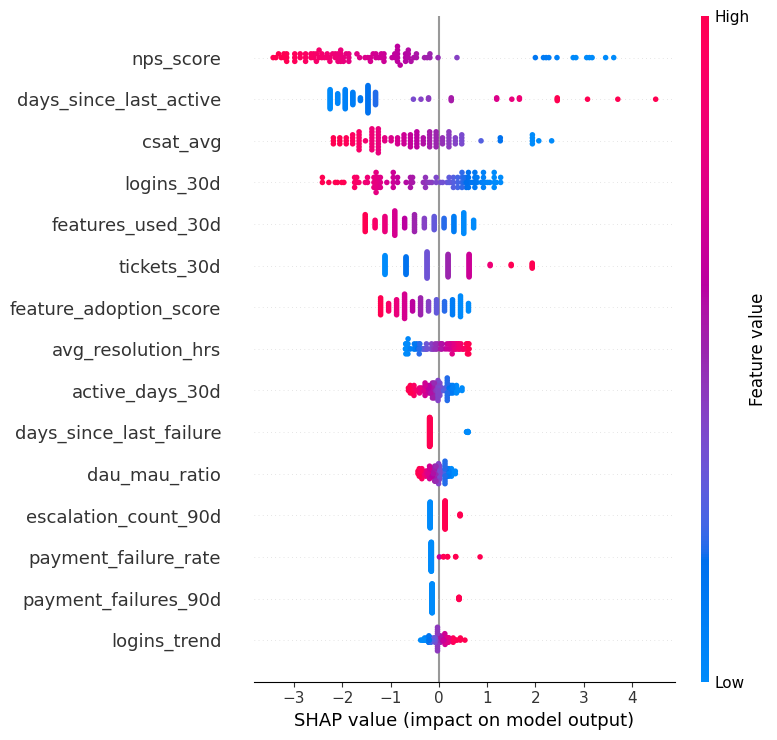

In [30]:
def plot_global_importance(
    explainer,
    X_test: pd.DataFrame,
    feature_names: list[str],
) -> None:
    """Plot mean absolute SHAP values for the top 15 features globally.

    Generates a Plotly horizontal bar chart and a matplotlib beeswarm summary plot.

    Parameters
    ----------
    explainer : shap.TreeExplainer or shap.LinearExplainer
        Fitted SHAP explainer.
    X_test : pd.DataFrame
        Test feature matrix.
    feature_names : list[str]
        Column names corresponding to X_test features.
    """
    classifier = BEST_MODEL.named_steps["classifier"]
    scaler = BEST_MODEL.named_steps.get("scaler")

    if isinstance(classifier, (XGBClassifier, LGBMClassifier)):
        X_input = X_test.values
    else:
        X_input = scaler.transform(X_test) if scaler else X_test.values

    shap_values = explainer.shap_values(X_input)
    if isinstance(shap_values, list):
        # Binary classification with LinearExplainer returns [class0, class1]
        shap_values = shap_values[1]

    mean_abs = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    importance_df = importance_df.sort_values("mean_abs_shap", ascending=False).head(15)

    fig = go.Figure(go.Bar(
        x=importance_df["mean_abs_shap"],
        y=importance_df["feature"],
        orientation="h",
        marker_color="#6366F1",
    ))
    fig.update_layout(
        title="Top Churn Risk Drivers Across All Customers (Mean |SHAP|)",
        xaxis_title="Mean |SHAP Value|",
        yaxis=dict(autorange="reversed"),
        template="plotly_white",
        height=500,
    )
    fig.show()

    # Matplotlib beeswarm
    shap.summary_plot(
        shap_values,
        X_test.values,
        feature_names=feature_names,
        max_display=15,
        show=True,
    )


FEATURE_NAMES = list(X.columns)
plot_global_importance(SHAP_EXPLAINER, X_test, FEATURE_NAMES)


In [31]:
_PLAIN_ENGLISH_TEMPLATES = {
    "days_since_last_active": "Has not logged in for {value:.0f} days (inactivity signal)",
    "payment_failures_90d": "{value:.0f} failed payment(s) in the last 90 days",
    "logins_trend": "Login volume changed {value:+.0%} vs. prior 30 days",
    "logins_30d": "Only {value:.0f} logins in the last 30 days",
    "feature_adoption_score": "Feature adoption at {value:.0%} of available features",
    "payment_failure_rate": "{value:.0%} of recent payments failed",
    "mrr_change_pct": "MRR changed {value:+.1f}% over 90 days",
    "months_of_tenure": "Customer for {value:.0f} months",
    "seat_utilization": "Only {value:.0%} of licensed seats are active",
    "tickets_30d": "Opened {value:.0f} support ticket(s) this month",
    "ticket_velocity_change": "Support ticket volume changed {value:+.0%} vs. prior period",
    "csat_avg": "Average CSAT score is {value:.1f}/5.0",
    "nps_score": "NPS score is {value:.0f}",
    "escalation_count_90d": "{value:.0f} escalated ticket(s) in 90 days",
    "has_downgraded": "Customer downgraded their plan recently",
    "dau_mau_ratio": "DAU/MAU ratio is {value:.2f} (engagement depth)",
    "active_days_30d": "Active on only {value:.0f} days in the last 30 days",
    "monthly_revenue": "Monthly revenue is ${value:.0f}",
}


def _to_plain_english(feature: str, value: float) -> str:
    """Convert a feature-value pair to a plain-English churn signal description.

    Parameters
    ----------
    feature : str
        Feature column name.
    value : float
        Observed value for this feature.

    Returns
    -------
    str
        Human-readable description.
    """
    template = _PLAIN_ENGLISH_TEMPLATES.get(feature)
    if template:
        try:
            return template.format(value=value)
        except (KeyError, ValueError):
            return f"{feature} = {value:.3f}"
    return f"{feature} = {value:.3f}"


def explain_customer_risk(
    customer_id: str,
    scored_df: pd.DataFrame,
    explainer,
    X: pd.DataFrame,
    feature_names: list[str],
) -> dict:
    """Compute SHAP values for a single customer and identify top risk drivers.

    Parameters
    ----------
    customer_id : str
        The customer's unique identifier.
    scored_df : pd.DataFrame
        Scored customer DataFrame with 'customer_id', 'churn_probability', 'risk_tier'.
    explainer : shap.explainer
        Fitted SHAP explainer.
    X : pd.DataFrame
        Full feature matrix aligned with scored_df rows.
    feature_names : list[str]
        Feature column names.

    Returns
    -------
    dict
        Keys: customer_id, churn_probability, risk_tier, top_risk_drivers, shap_values.

    Raises
    ------
    ValueError
        If the customer_id is not found in scored_df.
    """
    if "customer_id" not in scored_df.columns:
        raise ValueError("scored_df must contain a 'customer_id' column.")

    row_mask = scored_df["customer_id"] == customer_id
    if not row_mask.any():
        raise ValueError(f"customer_id '{customer_id}' not found in scored_df.")

    row_idx = scored_df[row_mask].index[0]
    customer_row = scored_df.loc[row_idx]
    x_row = X.loc[row_idx:row_idx]

    classifier = BEST_MODEL.named_steps["classifier"]
    scaler = BEST_MODEL.named_steps.get("scaler")

    if isinstance(classifier, (XGBClassifier, LGBMClassifier)):
        x_input = x_row.values
    else:
        x_input = scaler.transform(x_row) if scaler else x_row.values

    shap_vals = explainer.shap_values(x_input)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    shap_vals = np.array(shap_vals).flatten()

    top_idx = np.argsort(np.abs(shap_vals))[::-1][:5]
    drivers = []
    for idx in top_idx:
        feat = feature_names[idx]
        val = float(x_row.iloc[0, idx])
        drivers.append(_to_plain_english(feat, val))

    return {
        "customer_id": customer_id,
        "churn_probability": float(customer_row.get("churn_probability", 0)),
        "risk_tier": str(customer_row.get("risk_tier", "Unknown")),
        "top_risk_drivers": drivers,
        "shap_values": shap_vals.tolist(),
    }


# Demo: explain the top-priority customer
_top_customer_id = SCORED_DF.iloc[0]["customer_id"]
SAMPLE_EXPLANATION = explain_customer_risk(
    _top_customer_id, SCORED_DF, SHAP_EXPLAINER, X, FEATURE_NAMES
)
print(f"Customer: {SAMPLE_EXPLANATION['customer_id']}")
print(f"Churn probability: {SAMPLE_EXPLANATION['churn_probability']:.1f}%")
print(f"Risk tier: {SAMPLE_EXPLANATION['risk_tier']}")
print("Top risk drivers:")
for driver in SAMPLE_EXPLANATION["top_risk_drivers"]:
    print(f"  - {driver}")


Customer: cust_0372
Churn probability: 99.4%
Risk tier: Critical
Top risk drivers:
  - Has not logged in for 1 days (inactivity signal)
  - Average CSAT score is 4.7/5.0
  - Only 63 logins in the last 30 days
  - NPS score is 32
  - Opened 4 support ticket(s) this month


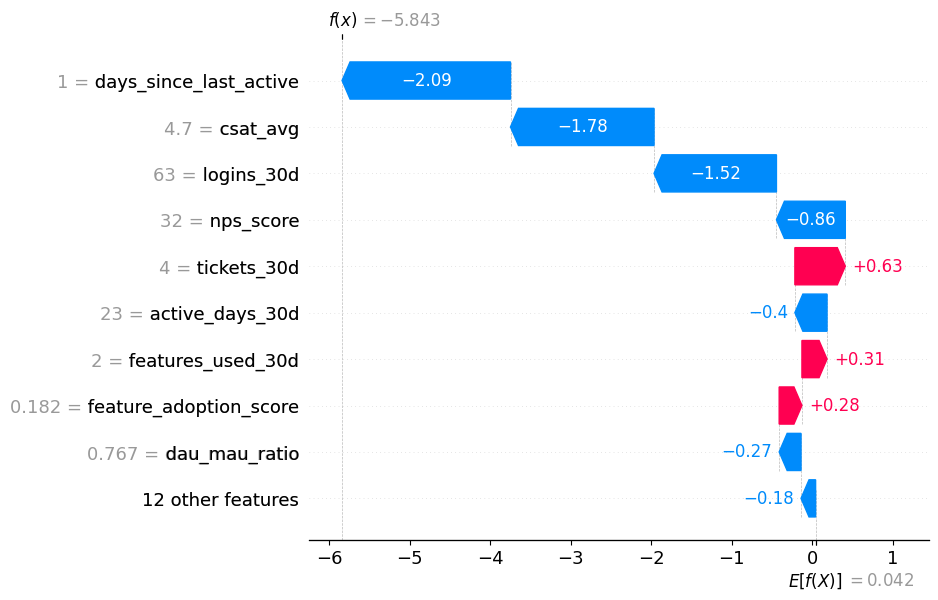

In [32]:
def plot_customer_waterfall(
    customer_id: str,
    explainer,
    X: pd.DataFrame,
    feature_names: list[str],
) -> None:
    """Generate a SHAP waterfall plot for a single customer.

    Shows how each feature pushes the model prediction above or below
    the baseline (mean) churn probability.

    Parameters
    ----------
    customer_id : str
        Customer identifier to look up in SCORED_DF.
    explainer : shap.explainer
        Fitted SHAP explainer.
    X : pd.DataFrame
        Full feature matrix.
    feature_names : list[str]
        Feature column names.
    """
    row_mask = SCORED_DF["customer_id"] == customer_id
    if not row_mask.any():
        print(f"Customer '{customer_id}' not found.")
        return

    row_idx = SCORED_DF[row_mask].index[0]
    x_row = X.loc[row_idx:row_idx]

    classifier = BEST_MODEL.named_steps["classifier"]
    scaler = BEST_MODEL.named_steps.get("scaler")

    if isinstance(classifier, (XGBClassifier, LGBMClassifier)):
        x_input = x_row.values
    else:
        x_input = scaler.transform(x_row) if scaler else x_row.values

    shap_vals = explainer.shap_values(x_input)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    shap_vals = np.array(shap_vals).flatten()

    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = float(base_value[1])

    explanation = shap.Explanation(
        values=shap_vals,
        base_values=float(base_value),
        data=x_row.values.flatten(),
        feature_names=feature_names,
    )
    shap.plots.waterfall(explanation, show=True)


plot_customer_waterfall(_top_customer_id, SHAP_EXPLAINER, X, FEATURE_NAMES)


## Section 7 -- LLM-Powered Intervention Plans

Rule-based interventions ("high-risk -> schedule a call") cannot account for the
specific combination of signals that make each customer's situation unique. An LLM
integrates the full context -- churn probability, SHAP-derived drivers, tenure, MRR,
and plan type -- into a concrete, personalized 30-day retention playbook.

**Free-tier fallback chain:**
1. **Groq** (`llama-3.3-70b-versatile`) -- 500K tokens/day free. Primary provider.
2. **Google Gemini** (`gemini-2.0-flash-lite`) -- 1,000 requests/day free. First fallback.
3. **OpenRouter** (`meta-llama/llama-3.3-70b-instruct:free`) -- Emergency fallback.
4. **Template-based** -- No API required. Always available.

If any provider exhausts its free tier or returns an error, the chain progresses
automatically. The notebook continues producing actionable plans regardless.


In [33]:
def build_intervention_prompt(customer_data: dict) -> str:
    """Build an LLM prompt from a customer's risk profile.

    Parameters
    ----------
    customer_data : dict
        Output of explain_customer_risk() with additional customer metadata.

    Returns
    -------
    str
        Formatted prompt string ready to send to an LLM.
    """
    cid = customer_data.get("customer_id", "unknown")
    prob = customer_data.get("churn_probability", 0)
    tier = customer_data.get("risk_tier", "High")
    drivers = customer_data.get("top_risk_drivers", [])
    mrr = customer_data.get("monthly_revenue", 0)
    tenure = customer_data.get("months_of_tenure", 0)
    plan = customer_data.get("plan_name", "unknown")
    days_inactive = customer_data.get("days_since_last_active", 0)
    pay_fails = customer_data.get("payment_failures_90d", 0)
    contract = customer_data.get("contract_type", "monthly")

    drivers_text = "\n".join(f"  - {d}" for d in drivers[:3]) if drivers else "  - No specific drivers identified."

    prompt = (
        f"You are a customer success expert. Generate a specific 30-day retention "
        f"plan for this at-risk SaaS customer. Keep your response under 380 words.\n\n"
        f"CUSTOMER PROFILE\n"
        f"  ID: {cid}\n"
        f"  Churn probability: {prob:.1f}% ({tier} risk)\n"
        f"  Plan: {plan} | MRR: ${mrr:.0f}/month | Contract: {contract}\n"
        f"  Tenure: {tenure:.0f} months\n"
        f"  Days since last active: {days_inactive:.0f}\n"
        f"  Failed payments (90d): {pay_fails:.0f}\n\n"
        f"TOP 3 CHURN RISK DRIVERS\n{drivers_text}\n\n"
        f"Structure your response exactly as:\n"
        f"(1) Immediate Action (within 24 hours):\n"
        f"(2) Week 1 Strategy:\n"
        f"(3) Week 2-3 Follow-up:\n"
        f"(4) Two measurable success metrics:\n\n"
        f"Be specific about messaging, offer amounts if relevant, and who should "
        f"own each action. Write in plain, direct language."
    )
    return prompt


In [34]:
def get_llm_client() -> dict:
    """Initialize an LLM client based on available API keys.

    Attempts Groq first, then Gemini, then OpenRouter. Falls back to a
    template-based provider if no keys are configured.

    Returns
    -------
    dict
        Keys: 'provider' (str), 'client' (object or None), 'model' (str or None).
    """
    if GROQ_API_KEY and groq_sdk:
        try:
            client = groq_sdk.Groq(api_key=GROQ_API_KEY)
            return {"provider": "groq", "client": client, "model": "llama-3.3-70b-versatile"}
        except Exception:
            pass

    if GEMINI_API_KEY and genai:
        try:
            genai.configure(api_key=GEMINI_API_KEY)
            gemini_model = genai.GenerativeModel("gemini-2.0-flash-lite")
            return {"provider": "gemini", "client": gemini_model, "model": "gemini-2.0-flash-lite"}
        except Exception:
            pass

    if OPENROUTER_API_KEY:
        return {
            "provider": "openrouter",
            "client": None,
            "model": "meta-llama/llama-3.3-70b-instruct:free",
        }

    return {"provider": "template", "client": None, "model": None}


def _call_groq(prompt: str, client, model: str, config: dict) -> str:
    """Call the Groq chat completions API.

    Parameters
    ----------
    prompt : str
        The user prompt.
    client : groq.Groq
        Initialized Groq client.
    model : str
        Model name to use.
    config : dict
        CONFIG dict with 'llm_max_tokens' and 'llm_temperature'.

    Returns
    -------
    str
        Generated text response.
    """
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=config["llm_max_tokens"],
        temperature=config["llm_temperature"],
    )
    return response.choices[0].message.content


def _call_gemini(prompt: str, client) -> str:
    """Call the Google Gemini API.

    Parameters
    ----------
    prompt : str
        The user prompt.
    client : genai.GenerativeModel
        Initialized Gemini model instance.

    Returns
    -------
    str
        Generated text response.
    """
    response = client.generate_content(prompt)
    return response.text


def _call_openrouter(prompt: str, model: str, config: dict) -> str:
    """Call the OpenRouter API via HTTP POST.

    Parameters
    ----------
    prompt : str
        The user prompt.
    model : str
        OpenRouter model identifier.
    config : dict
        CONFIG dict with 'llm_max_tokens' and 'llm_temperature'.

    Returns
    -------
    str
        Generated text response.

    Raises
    ------
    RuntimeError
        If the API request fails.
    """
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": config["llm_max_tokens"],
        "temperature": config["llm_temperature"],
    }
    resp = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers=headers,
        json=payload,
        timeout=30,
    )
    resp.raise_for_status()
    return resp.json()["choices"][0]["message"]["content"]


def call_llm(prompt: str, llm_config: dict, config: dict) -> tuple[str, str]:
    """Route a prompt to the configured LLM provider with automatic fallback.

    Fallback chain: Groq -> Gemini -> OpenRouter -> template.

    Parameters
    ----------
    prompt : str
        The intervention prompt.
    llm_config : dict
        Output of get_llm_client().
    config : dict
        CONFIG dict.

    Returns
    -------
    tuple[str, str]
        (generated_text, provider_name_used).
    """
    provider = llm_config["provider"]
    client = llm_config["client"]
    model = llm_config["model"]

    if provider == "groq" and groq_sdk:
        try:
            return _call_groq(prompt, client, model, config), "groq"
        except groq_sdk.RateLimitError:
            print("Groq rate limit hit. Falling back to Gemini.")
        except Exception as exc:
            print(f"Groq error: {exc}. Falling back.")

    if GEMINI_API_KEY and genai:
        try:
            genai.configure(api_key=GEMINI_API_KEY)
            gem_model = genai.GenerativeModel("gemini-2.0-flash-lite")
            return _call_gemini(prompt, gem_model), "gemini"
        except Exception as exc:
            print(f"Gemini error: {exc}. Falling back.")

    if OPENROUTER_API_KEY:
        try:
            return _call_openrouter(prompt, "meta-llama/llama-3.3-70b-instruct:free", config), "openrouter"
        except requests.exceptions.RequestException as exc:
            print(f"OpenRouter error: {exc}. Using template fallback.")

    return generate_template_intervention({}), "template"


LLM_CONFIG = get_llm_client()
print(f"LLM provider configured: {LLM_CONFIG['provider']}")


LLM provider configured: groq


In [35]:
def generate_template_intervention(customer_data: dict) -> str:
    """Generate a structured retention plan using rule-based templates.

    Selects a template based on the top SHAP risk driver. This fallback
    produces actionable plans without requiring any external API.

    Parameters
    ----------
    customer_data : dict
        Customer data dict with 'top_risk_drivers', 'monthly_revenue', etc.

    Returns
    -------
    str
        Formatted retention action plan.
    """
    drivers = customer_data.get("top_risk_drivers", [])
    top_driver = drivers[0].lower() if drivers else ""
    mrr = customer_data.get("monthly_revenue", 0)
    cid = customer_data.get("customer_id", "this customer")

    if any(kw in top_driver for kw in ["payment", "failed", "failure"]):
        return (
            f"(1) Immediate Action (within 24 hours):\n"
            f"    Contact {cid} via email with a direct payment update link. "
            f"Subject: 'Quick action needed on your account.' "
            f"Do not mention churn -- frame this as account maintenance.\n\n"
            f"(2) Week 1 Strategy:\n"
            f"    Call the billing contact. Offer a one-time payment plan if the "
            f"outstanding amount is >2x their monthly ${mrr:.0f} fee. "
            f"Update credit card details in Stripe and confirm auto-pay is enabled.\n\n"
            f"(3) Week 2-3 Follow-up:\n"
            f"    Send a health-check email from the founder/CEO if payment is still "
            f"unresolved. Consider a 2-week credit to reduce payment friction.\n\n"
            f"(4) Success Metrics:\n"
            f"    - Payment successfully processed within 7 days.\n"
            f"    - Customer active in-product within 14 days of payment resolution."
        )

    if any(kw in top_driver for kw in ["login", "active", "inactiv", "usage"]):
        return (
            f"(1) Immediate Action (within 24 hours):\n"
            f"    Send a personalised re-engagement email to {cid}. "
            f"Reference their specific use case. Include a direct link to the "
            f"feature most relevant to their plan.\n\n"
            f"(2) Week 1 Strategy:\n"
            f"    Schedule a 20-minute 'quick wins' call. "
            f"Prepare 2-3 use cases specific to their industry. "
            f"Offer a live demo of features they haven't used yet.\n\n"
            f"(3) Week 2-3 Follow-up:\n"
            f"    Send a 'Did you know?' educational sequence (3 emails over 10 days). "
            f"Track whether login frequency increases. "
            f"If no login within 21 days, escalate to account owner.\n\n"
            f"(4) Success Metrics:\n"
            f"    - At least 3 logins in the 14 days following outreach.\n"
            f"    - Feature adoption score increases by 20% within 30 days."
        )

    if any(kw in top_driver for kw in ["feature", "adoption"]):
        return (
            f"(1) Immediate Action (within 24 hours):\n"
            f"    Assign a CSM or onboarding specialist to {cid}. "
            f"Review which core features they have not activated.\n\n"
            f"(2) Week 1 Strategy:\n"
            f"    Run a personalised onboarding session focused on the top 2 unused "
            f"features. Provide a short 3-step 'quick start' guide specific to their workflow.\n\n"
            f"(3) Week 2-3 Follow-up:\n"
            f"    Check in via email on feature adoption. "
            f"Share a relevant case study (same industry/company size). "
            f"Offer 30 days of extended onboarding support.\n\n"
            f"(4) Success Metrics:\n"
            f"    - Customer activates at least 1 new core feature within 2 weeks.\n"
            f"    - Feature adoption score reaches 50%+ within 30 days."
        )

    # Default: MRR/plan change template
    return (
        f"(1) Immediate Action (within 24 hours):\n"
        f"    Reach out to {cid} to understand their current needs. "
        f"Ask open-ended questions about ROI and what success looks like for them.\n\n"
        f"(2) Week 1 Strategy:\n"
        f"    Present a value review showing measurable outcomes from their product usage. "
        f"If on a high-cost plan with low utilization, proactively offer a right-sized plan "
        f"to prevent an involuntary cancel.\n\n"
        f"(3) Week 2-3 Follow-up:\n"
        f"    Follow up with a written ROI summary. "
        f"If applicable, offer a 10-15% loyalty discount on annual commitment.\n\n"
        f"(4) Success Metrics:\n"
        f"    - Customer confirms continued subscription within 2 weeks.\n"
        f"    - No plan downgrade or cancellation within 60 days."
    )


In [36]:
def run_intervention_pipeline(
    scored_df: pd.DataFrame,
    explainer,
    X: pd.DataFrame,
    feature_names: list[str],
    llm_config: dict,
    config: dict,
    n_customers: int = 5,
) -> pd.DataFrame:
    """Run the full risk explanation + LLM intervention pipeline for top-n customers.

    Generates a 30-day retention plan per customer using SHAP risk drivers and the
    configured LLM provider. Implements a 1-second delay between LLM calls to respect
    free-tier rate limits.

    Parameters
    ----------
    scored_df : pd.DataFrame
        Scored customer DataFrame sorted by revenue_weighted_priority.
    explainer : shap.explainer
        Fitted SHAP explainer.
    X : pd.DataFrame
        Full feature matrix.
    feature_names : list[str]
        Feature column names.
    llm_config : dict
        LLM client configuration from get_llm_client().
    config : dict
        CONFIG dict.
    n_customers : int
        Number of top-priority customers to process.

    Returns
    -------
    pd.DataFrame
        scored_df with added columns: 'intervention_plan', 'llm_provider'.
    """
    result_df = scored_df.copy()
    result_df["intervention_plan"] = None
    result_df["llm_provider"] = None

    critical_mask = scored_df["churn_probability"] >= config["risk_threshold_critical"] * 100
    candidates = scored_df[critical_mask].head(n_customers)
    if candidates.empty:
        candidates = scored_df.head(n_customers)

    for _, row in candidates.iterrows():
        cid = row["customer_id"]
        try:
            explanation = explain_customer_risk(cid, scored_df, explainer, X, feature_names)
        except ValueError as exc:
            print(f"Skipping {cid}: {exc}")
            continue

        customer_context = {
            **explanation,
            "monthly_revenue": row.get("monthly_revenue", 0),
            "months_of_tenure": row.get("months_of_tenure", 0),
            "plan_name": row.get("plan_name", "unknown"),
            "days_since_last_active": row.get("days_since_last_active", 0),
            "payment_failures_90d": row.get("payment_failures_90d", 0),
            "contract_type": row.get("contract_type", "monthly"),
        }

        prompt = build_intervention_prompt(customer_context)
        plan_text, provider_used = call_llm(prompt, llm_config, config)

        row_mask = result_df["customer_id"] == cid
        result_df.loc[row_mask, "intervention_plan"] = plan_text
        result_df.loc[row_mask, "llm_provider"] = provider_used

        print("=" * 60)
        print(f"CUSTOMER: {cid} | RISK: {row.get('churn_probability', 0):.1f}% | "
              f"MRR: ${row.get('monthly_revenue', 0):.0f} | TIER: {row.get('risk_tier', 'N/A')}")
        print("TOP RISK DRIVERS:")
        for d in explanation["top_risk_drivers"][:3]:
            print(f"  - {d}")
        print("30-DAY RETENTION PLAN:")
        print(plan_text)
        print(f"Provider: {provider_used}")
        print()

        time.sleep(1)

    return result_df


INTERVENTION_DF = run_intervention_pipeline(
    SCORED_DF, SHAP_EXPLAINER, X, FEATURE_NAMES, LLM_CONFIG, CONFIG, n_customers=5
)


CUSTOMER: cust_0372 | RISK: 99.4% | MRR: $1078 | TIER: Critical
TOP RISK DRIVERS:
  - Has not logged in for 1 days (inactivity signal)
  - Average CSAT score is 4.7/5.0
  - Only 63 logins in the last 30 days
30-DAY RETENTION PLAN:
(1) Immediate Action (within 24 hours):
The Customer Success Manager (CSM) will send a personalized email to cust_0372 within 24 hours, checking in on their experience and offering assistance with onboarding. The email will include a brief introduction, a link to a getting-started guide, and an invitation to schedule a call to discuss any questions or concerns.

(2) Week 1 Strategy:
The CSM will follow up with a phone call to cust_0372, aiming to understand their goals and objectives, and to identify potential pain points. The CSM will also offer a complimentary onboarding session, valued at $200, to help the customer get the most out of the platform.

(3) Week 2-3 Follow-up:
The CSM will schedule regular check-ins with cust_0372 to monitor progress, provide 

## Section 8 -- Persistence, Export & Action

A notebook run produces a point-in-time snapshot. SQLite persistence enables:

- **Week-over-week comparison**: Did the critical segment shrink or grow?
- **Intervention tracking**: Did the customers your CS team contacted actually stay?
- **Model improvement**: After 3 months of outcome data, retrain on saved/churned labels
  to improve precision beyond what the initial model achieves.

All results are also exported as dated CSV files for distribution to CS teams and
optional import into your CRM.


In [37]:
def initialize_database(db_path: str) -> None:
    """Create the SQLite database and required tables if they do not exist.

    Tables:
    - churn_scores: per-customer risk scores from each run.
    - model_runs: metadata about each full notebook execution.
    - intervention_outcomes: CS team feedback on contacted customers.

    Parameters
    ----------
    db_path : str
        File path for the SQLite database.
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS churn_scores (
            customer_id     TEXT,
            run_date        TEXT,
            churn_probability REAL,
            risk_tier       TEXT,
            mrr_at_risk     REAL,
            top_risk_drivers TEXT,
            intervention_plan TEXT,
            PRIMARY KEY (customer_id, run_date)
        )
    """)

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS model_runs (
            run_id          TEXT PRIMARY KEY,
            run_date        TEXT,
            model_type      TEXT,
            roc_auc         REAL,
            pr_auc          REAL,
            customer_count  INTEGER,
            churn_rate      REAL,
            config_snapshot TEXT
        )
    """)

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS intervention_outcomes (
            customer_id         TEXT,
            intervention_date   TEXT,
            outcome             TEXT,
            notes               TEXT
        )
    """)

    conn.commit()
    conn.close()
    print(f"Database initialized at: {db_path}")


initialize_database(CONFIG["db_path"])


Database initialized at: churnguard.db


In [38]:
def save_run_results(
    scored_df: pd.DataFrame,
    eval_metrics: pd.DataFrame,
    config: dict,
    db_path: str,
) -> None:
    """Persist the current run's model metrics and customer scores to SQLite.

    Uses INSERT OR REPLACE for upsert semantics on (customer_id, run_date).

    Parameters
    ----------
    scored_df : pd.DataFrame
        Output of score_customers() with optional intervention_plan column.
    eval_metrics : pd.DataFrame
        Output of evaluate_models().
    config : dict
        CONFIG dict (saved as JSON in model_runs).
    db_path : str
        SQLite database path.
    """
    run_date = date.today().isoformat()
    run_id = f"run_{run_date}_{BEST_MODEL_NAME}"

    best_metrics = eval_metrics.iloc[0]
    config_json = json.dumps(config, default=str)

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute(
        """
        INSERT OR REPLACE INTO model_runs
            (run_id, run_date, model_type, roc_auc, pr_auc,
             customer_count, churn_rate, config_snapshot)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """,
        (
            run_id, run_date, BEST_MODEL_NAME,
            float(best_metrics.get("roc_auc", 0)),
            float(best_metrics.get("pr_auc", 0)),
            len(scored_df),
            float(scored_df["is_churned"].mean()) if "is_churned" in scored_df.columns else 0.0,
            config_json,
        ),
    )

    score_rows = []
    for _, row in scored_df.iterrows():
        drivers = row.get("top_risk_drivers", [])
        drivers_json = json.dumps(drivers) if isinstance(drivers, list) else str(drivers)
        score_rows.append((
            str(row["customer_id"]),
            run_date,
            float(row.get("churn_probability", 0)),
            str(row.get("risk_tier", "Low")),
            float(row.get("mrr_at_risk", 0)),
            drivers_json,
            str(row.get("intervention_plan", "")),
        ))

    cursor.executemany(
        """
        INSERT OR REPLACE INTO churn_scores
            (customer_id, run_date, churn_probability, risk_tier,
             mrr_at_risk, top_risk_drivers, intervention_plan)
        VALUES (?, ?, ?, ?, ?, ?, ?)
        """,
        score_rows,
    )

    conn.commit()
    conn.close()
    print(f"Saved {len(score_rows)} customer scores and 1 model run to {db_path}.")


save_run_results(INTERVENTION_DF, EVAL_RESULTS, CONFIG, CONFIG["db_path"])


Saved 500 customer scores and 1 model run to churnguard.db.


In [39]:
def record_intervention_outcome(
    customer_id: str,
    outcome: str,
    notes: str,
    db_path: str,
) -> None:
    """Log the outcome of a CS intervention for a specific customer.

    This is the feedback loop entry point. Record outcomes after each customer
    contact so the outcome data can be used to validate and retrain the model.

    Parameters
    ----------
    customer_id : str
        The customer's unique identifier.
    outcome : str
        One of: 'saved', 'churned', 'unknown'.
    notes : str
        Free-text notes (e.g., reason given by customer, action taken).
    db_path : str
        SQLite database path.

    Raises
    ------
    ValueError
        If outcome is not one of the accepted values.
    """
    valid_outcomes = {"saved", "churned", "unknown"}
    if outcome not in valid_outcomes:
        raise ValueError(f"outcome must be one of {valid_outcomes}. Got: '{outcome}'.")

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(
        """
        INSERT INTO intervention_outcomes (customer_id, intervention_date, outcome, notes)
        VALUES (?, ?, ?, ?)
        """,
        (customer_id, date.today().isoformat(), outcome, notes),
    )
    conn.commit()
    conn.close()
    print(f"Outcome recorded: {customer_id} -> {outcome}")


# Example: uncomment and fill in your own customer_id and outcome
# record_intervention_outcome("cust_0001", "saved", "Offered 20% discount, customer renewed.")


In [40]:
def export_results(
    scored_df: pd.DataFrame,
    output_dir: str,
) -> dict[str, str]:
    """Export scored results to dated CSV files in the output directory.

    Exports:
    - All customers (full scored DataFrame).
    - Critical-risk customers only.
    - Customers with intervention plans.
    - Revenue summary as a single-row CSV.

    Parameters
    ----------
    scored_df : pd.DataFrame
        Full scored DataFrame from run_intervention_pipeline().
    output_dir : str
        Directory path to write output files.

    Returns
    -------
    dict[str, str]
        Mapping of report name to file path.
    """
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    today_str = date.today().strftime("%Y%m%d")
    paths = {}

    all_path = os.path.join(output_dir, f"churnguard_all_customers_{today_str}.csv")
    scored_df.to_csv(all_path, index=False)
    paths["all_customers"] = all_path

    critical_df = scored_df[scored_df["risk_tier"] == "Critical"]
    crit_path = os.path.join(output_dir, f"churnguard_critical_risk_{today_str}.csv")
    critical_df.to_csv(crit_path, index=False)
    paths["critical_risk"] = crit_path

    if "intervention_plan" in scored_df.columns:
        plan_df = scored_df[scored_df["intervention_plan"].notna()]
        plan_path = os.path.join(output_dir, f"churnguard_intervention_plans_{today_str}.csv")
        plan_df.to_csv(plan_path, index=False)
        paths["intervention_plans"] = plan_path

    summary_data = {
        "run_date": today_str,
        "total_customers": len(scored_df),
        "critical_count": len(scored_df[scored_df["risk_tier"] == "Critical"]),
        "total_mrr_at_risk": scored_df.get("mrr_at_risk", pd.Series(dtype=float)).sum(),
    }
    rev_path = os.path.join(output_dir, f"churnguard_revenue_summary_{today_str}.csv")
    pd.DataFrame([summary_data]).to_csv(rev_path, index=False)
    paths["revenue_summary"] = rev_path

    print(f"{'Report':<30} {'File':<55} {'Rows'}")
    print("-" * 90)
    for name, fpath in paths.items():
        row_count = len(pd.read_csv(fpath))
        print(f"{name:<30} {os.path.basename(fpath):<55} {row_count}")

    return paths


EXPORT_PATHS = export_results(INTERVENTION_DF, CONFIG["output_dir"])


Report                         File                                                    Rows
------------------------------------------------------------------------------------------
all_customers                  churnguard_all_customers_20260304.csv                   500
critical_risk                  churnguard_critical_risk_20260304.csv                   90
intervention_plans             churnguard_intervention_plans_20260304.csv              5
revenue_summary                churnguard_revenue_summary_20260304.csv                 1


In [41]:
def push_risk_scores_to_hubspot(
    scored_df: pd.DataFrame,
    access_token: str,
) -> None:
    """Update HubSpot contacts with ChurnGuard risk scores and tier.

    Creates or updates custom contact properties 'churnguard_risk_score' and
    'churnguard_risk_tier'. Only runs if HUBSPOT_ACCESS_TOKEN is set.

    Parameters
    ----------
    scored_df : pd.DataFrame
        Scored DataFrame with 'customer_id', 'churn_probability', 'risk_tier'.
    access_token : str
        HubSpot private app access token.

    Raises
    ------
    ImportError
        If the hubspot-api-client package is not installed.
    """
    if HubSpotClient is None:
        raise ImportError("hubspot-api-client not installed.")

    client = HubSpotClient.create(access_token=access_token)
    updated = 0
    failed = 0

    for _, row in scored_df.iterrows():
        contact_id = str(row["customer_id"])
        props = {
            "churnguard_risk_score": str(row.get("churn_probability", 0)),
            "churnguard_risk_tier": str(row.get("risk_tier", "Low")),
        }
        try:
            client.crm.contacts.basic_api.update(
                contact_id=contact_id,
                simple_public_object_input={"properties": props},
            )
            updated += 1
        except HubSpotApiException as exc:
            print(f"HubSpot update failed for {contact_id}: {exc.reason}")
            failed += 1

    print(f"HubSpot sync: {updated} contacts updated, {failed} failed.")


if HUBSPOT_ACCESS_TOKEN:
    push_risk_scores_to_hubspot(INTERVENTION_DF, HUBSPOT_ACCESS_TOKEN)
else:
    print("HUBSPOT_ACCESS_TOKEN not set. Skipping CRM sync.")


HUBSPOT_ACCESS_TOKEN not set. Skipping CRM sync.


## Section 9 -- Limitations, Next Steps & Re-Run Guide

### Known Limitations

**Minimum data requirements:** ChurnGuard needs 100+ customers and 30+ churn events
for meaningful ML predictions. With smaller datasets, treat the risk scores as
exploratory signals, not production decisions. The validation report in Section 2
will warn you if your dataset is below these thresholds.

**Cold start problem:** Customers in their first 14 days have no behavioral history.
The model cannot reliably score them. Manage new customers through onboarding
playbooks, not churn prediction. Flag new customers in your CRM for manual check-ins
at days 7, 14, and 30.

**Correlation, not causation:** A declining usage score predicts churn but does not
prove it. The customer might be on vacation, have changed workflows, or be mid-renewal
negotiation. Treat every flag as "worth a conversation," not "definitely leaving."
Use SHAP explanations to make that conversation specific and relevant.

**Free LLM tier instability:** Groq, Gemini, and OpenRouter have changed their free
tiers without notice in the past. If API calls fail, the template fallback in Section 7
generates actionable plans without any external dependencies. Check provider status
pages before running large batches.

**Point-in-time analysis:** Risk scores go stale. Re-run this notebook monthly
(or weekly for high-churn businesses) to keep scores current. For automated execution,
consider GitHub Actions with a scheduled workflow.

---

### Next Steps

| Action | Effort |
|--------|--------|
| Add your own data source via the connector pattern in Section 1 | 2-4 hours |
| Record intervention outcomes using `record_intervention_outcome()` after each CS contact | 5 min/customer |
| After 3+ months of outcome data, retrain on `is_saved` labels | 1 hour |
| At $1M+ ARR, evaluate Vitally (free up to $1M ARR) or Baremetrics | 1 day |
| Add Paddle, Chargebee, or Lemon Squeezy connectors via the Stripe pattern | 2-3 hours each |

---

### Monthly Re-Run Checklist

1. Export fresh customer data from your billing and analytics tools.
2. Replace demo data with new exports, or re-run API connectors.
3. Run all cells top to bottom.
4. Review the risk summary and compare to last month's run in SQLite.
5. Record outcomes for customers who were contacted last month.
6. Export and distribute the intervention plan CSV to your CS team.
